```
# Deep Quantum Neural Network (DQNN) for FashionMNIST using PennyLane + PyTorch
# Install:
# pip install torch torchvision pennylane tqdm


Classical Neural Network
        ↓
Variational Quantum Circuit (VQC)
        ↓
Classical Classifier
```


---
## Overall Data Flow
```
28×28 Image
      │
      ▼
Flatten (784)
      │
      ▼
Classical Dense Network
784 → 256 → 128 → NUM_QUBITS
      │
      ▼
Quantum Circuit
AngleEmbedding
      │
StronglyEntanglingLayers
      │
Expectation Values (<Zi>)
      │
      ▼
Dense Classifier
NUM_QUBITS → 64 → 10
      │
      ▼
Softmax (via CrossEntropyLoss during training)
      │
      ▼
Predicted Digit (0–9)
```

In [1]:
!pip install pennylane torch torchvision matplotlib scikit-learn seaborn -q 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 91.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import pennylane as qml
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import io
import torch
from PIL import Image, ImageOps
import torchvision.transforms as transforms
from ipywidgets import FileUpload, Button, Output, VBox, Label
from IPython.display import display
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import pennylane as qml
# ============================================================
# SIMAM-Enhanced Hybrid Quantum-Classical Neural Network
# FashionMNIST Classification
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import pennylane as qml

from tqdm.auto import tqdm

from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

print("🔥Imports Loaded!!!")

🔥Imports Loaded!!!


Using Seed: 42
Using device: cpu


100%|██████████| 18.2M/18.2M [00:15<00:00, 1.19MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 316kB/s]
100%|██████████| 3.04M/3.04M [00:01<00:00, 1.69MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 11.8MB/s]



DATASET INFORMATION
Original FashionMNIST training dataset : 60,000
Selected dataset fraction               : 10.0%
Selected samples                        : 6,000
Training samples                        : 4,200 (7.00% of original)
Validation samples                      : 900 (1.50% of original)
Internal test samples                   : 900 (1.50% of original)
Official test samples                   : 10,000

Training class distribution:
Counter({np.int64(2): 453, np.int64(7): 445, np.int64(1): 435, np.int64(0): 432, np.int64(4): 428, np.int64(6): 426, np.int64(9): 421, np.int64(5): 404, np.int64(3): 379, np.int64(8): 377})

Validation class distribution:
Counter({np.int64(6): 106, np.int64(1): 95, np.int64(2): 92, np.int64(4): 92, np.int64(0): 90, np.int64(5): 89, np.int64(3): 89, np.int64(7): 86, np.int64(8): 85, np.int64(9): 76})

Internal test class distribution:
Counter({np.int64(5): 104, np.int64(2): 102, np.int64(7): 94, np.int64(8): 92, np.int64(3): 91, np.int64(0): 87, np.in

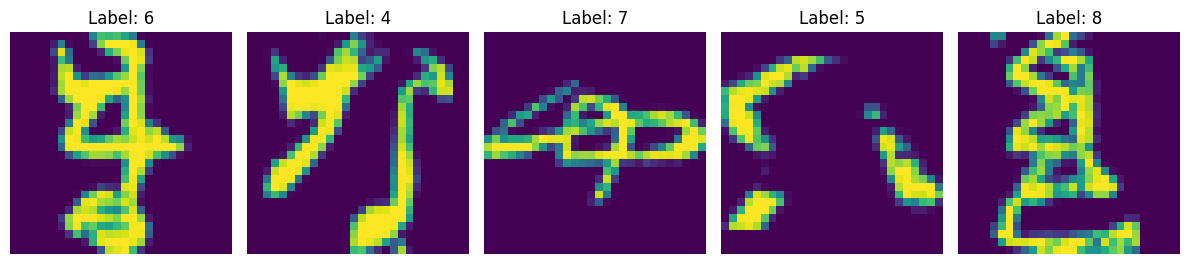


Number of Classes: 10


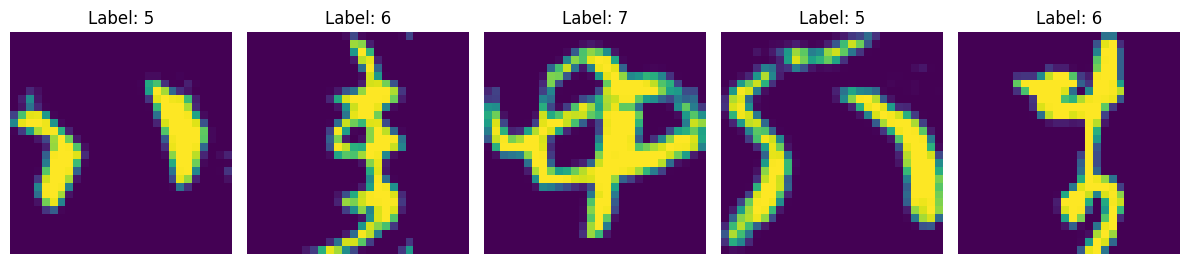


MODEL ARCHITECTURE
DeepQNN(
  (simam): SIMAM()
  (classical): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 236,258
Trainable Parameters : 236,258
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 2.2459 | Train Acc: 23.81% | Val Loss: 2.1572 | Val Acc: 39.67%


Epoch 2/25 [Train]:   0%|          | 0/66 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 0.0092 | Train Acc: 99.93% | Val Loss: 0.5083 | Val Acc: 89.33%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 75.09%

Sample Prediction
-----------------
True Label     : 2
Predicted Label: 6


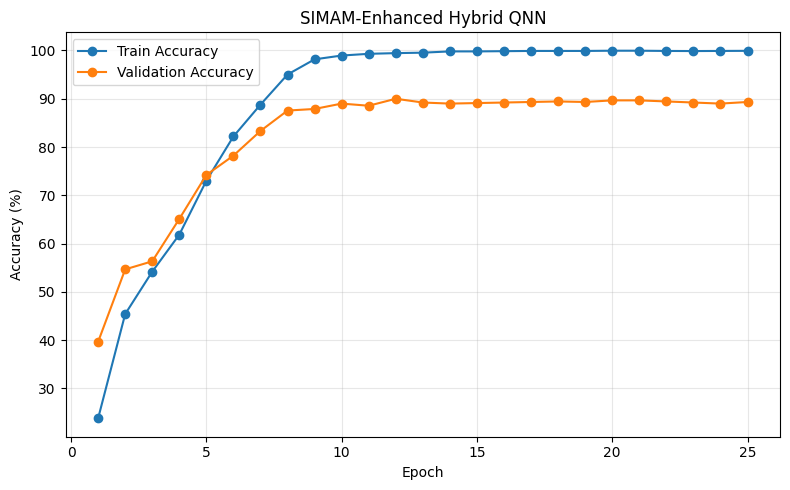

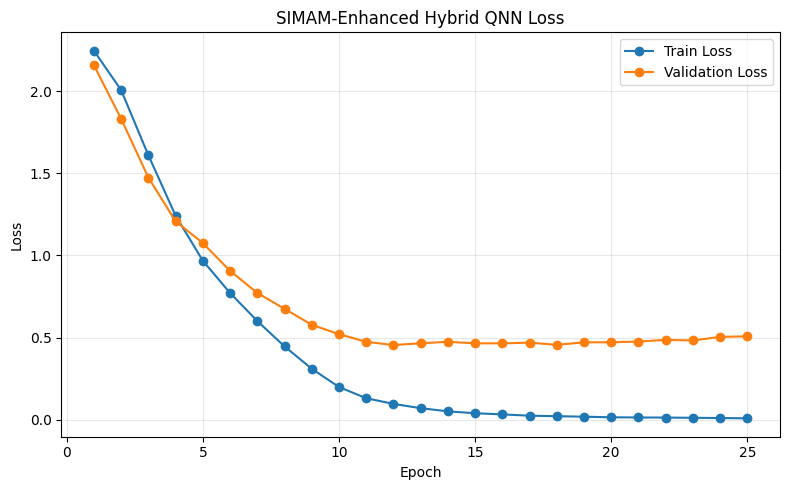

In [ ]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

# ============================================================
# Dataset & Data Processing
# ============================================================

# ------------------------------------------------------------
# Dataset Fractions
# ------------------------------------------------------------

DATASET_FRACTION = 0.10

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
INTERNAL_TEST_FRACTION = 0.15


# ============================================================
# Transform
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    ),
])


# ============================================================
# Load Full FashionMNIST Training Dataset
# ============================================================

full_train_dataset = datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# ============================================================
# Load Official FashionMNIST Test Dataset
#
# IMPORTANT:
# This dataset is completely untouched.
# It is used ONLY for final evaluation.
# ============================================================

official_test_dataset = datasets.KMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Select 10% of Original Training Dataset
# ============================================================

total_train_samples = len(full_train_dataset)

selected_size = int(
    total_train_samples * DATASET_FRACTION
)


selected_dataset, _ = random_split(
    full_train_dataset,
    [
        selected_size,
        total_train_samples - selected_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Split Selected 10%
#
# 70% → Train
# 15% → Validation
# 15% → Internal Test
#
# Overall:
#
# 10% × 70% = 7%
# 10% × 15% = 1.5%
# 10% × 15% = 1.5%
# ============================================================

train_size = int(
    selected_size * TRAIN_FRACTION
)

val_size = int(
    selected_size * VAL_FRACTION
)

internal_test_size = (
    selected_size
    - train_size
    - val_size
)


train_dataset, val_dataset, internal_test_dataset = random_split(
    selected_dataset,
    [
        train_size,
        val_size,
        internal_test_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Dataset Information
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(
    f"Original FashionMNIST training dataset : "
    f"{total_train_samples:,}"
)

print(
    f"Selected dataset fraction               : "
    f"{DATASET_FRACTION * 100:.1f}%"
)

print(
    f"Selected samples                        : "
    f"{selected_size:,}"
)

print(
    f"Training samples                        : "
    f"{len(train_dataset):,} "
    f"({len(train_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Validation samples                      : "
    f"{len(val_dataset):,} "
    f"({len(val_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Internal test samples                   : "
    f"{len(internal_test_dataset):,} "
    f"({len(internal_test_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Official test samples                   : "
    f"{len(official_test_dataset):,}"
)

print("=" * 60)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Official FashionMNIST test set
test_loader = DataLoader(
    official_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Recover Original Indices
# ============================================================

selected_indices = selected_dataset.indices

train_indices = train_dataset.indices
val_indices = val_dataset.indices
internal_test_indices = internal_test_dataset.indices


train_original_indices = [
    selected_indices[i]
    for i in train_indices
]

val_original_indices = [
    selected_indices[i]
    for i in val_indices
]

internal_test_original_indices = [
    selected_indices[i]
    for i in internal_test_indices
]


# ============================================================
# Extract Labels
# ============================================================

train_labels = (
    full_train_dataset
    .targets[train_original_indices]
    .numpy()
)

val_labels = (
    full_train_dataset
    .targets[val_original_indices]
    .numpy()
)

internal_test_labels = (
    full_train_dataset
    .targets[internal_test_original_indices]
    .numpy()
)

official_test_labels = (
    official_test_dataset
    .targets
    .numpy()
)


# ============================================================
# Class Distribution
# ============================================================

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nValidation class distribution:")
print(Counter(val_labels))

print("\nInternal test class distribution:")
print(Counter(internal_test_labels))

print("\nOfficial test class distribution:")
print(Counter(official_test_labels))


# ============================================================
# Class Weights
# ============================================================
#
# IMPORTANT:
# Calculate class weights ONLY from training data.
# Do NOT use validation or test labels.
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)


print("\nClass Weights:")
print("-" * 30)

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# Number of Classes
# ============================================================

NUM_CLASSES = len(
    torch.unique(
        full_train_dataset.targets
    )
)

print(
    f"\nNumber of Classes: {NUM_CLASSES}"
)

# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(
        img,
        # cmap="gray"
    )

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()

# ============================================================
# Number of Classes — Automatically Detected
# ============================================================

NUM_CLASSES = len(torch.unique(full_train_dataset.targets))

print(f"Number of Classes: {NUM_CLASSES}")


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

class DeepQNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()


        # ====================================================
        # 1. SIMAM Attention
        # ====================================================

        self.simam = SIMAM(
            e_lambda=SIMAM_E_LAMBDA
        )


        # ====================================================
        # 2. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 784 → 256
            nn.Linear(
                784,
                256
            ),

            nn.ReLU(),


            # 256 → 128
            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            # 128 → NUM_QUBITS
            nn.Linear(
                128,
                NUM_QUBITS
            )

        )


        # ====================================================
        # 3. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer


        # ====================================================
        # 4. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # NUM_QUBITS → 64
            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.ReLU(),


            # 64 → 10
            nn.Linear(
                64,
                num_classes
            )

        )


    # ========================================================
    # Forward Pass
    # ========================================================

    def forward(self, x):


        # ====================================================
        # STEP 1 — Input
        # ====================================================
        #
        # x:
        #
        # [B, 1, 28, 28]
        #
        # ====================================================


        # ====================================================
        # STEP 2 — SIMAM
        # ====================================================

        x = self.simam(x)


        # ====================================================
        # STEP 3 — Flatten
        # ====================================================
        #
        # [B, 1, 28, 28]
        #
        #        ↓
        #
        # [B, 784]
        #
        # ====================================================

        x = x.flatten(
            start_dim=1
        )


        # ====================================================
        # STEP 4 — Classical Feature Extraction
        # ====================================================
        #
        # 784 → 256 → 128 → NUM_QUBITS
        #
        # ====================================================

        x = self.classical(x)


        # ====================================================
        # STEP 5 — Bound Quantum Angles
        # ====================================================
        #
        # tanh:
        #
        # [-∞, +∞] → [-1, +1]
        #
        # × π:
        #
        # [-1, +1] → [-π, +π]
        #
        # ====================================================

        x = torch.tanh(x) * np.pi


        # ====================================================
        # STEP 6 — Quantum Circuit
        # ====================================================

        quantum_device = x.device


        # default.qubit runs on CPU
        x = self.quantum(
            x.cpu()
        )


        # Move quantum output back
        # to original device

        x = x.to(
            quantum_device
        )


        # ====================================================
        # STEP 7 — Classical Classifier
        # ====================================================
        #
        # NUM_QUBITS → 64 → 10
        #
        # ====================================================

        x = self.classifier(x)


        return x


# ============================================================
# Create Model
# ============================================================

model = DeepQNN(
    num_classes=NUM_CLASSES
).to(DEVICE)

# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)

# ============================================================
# Predict One Official Test Sample
# ============================================================

image, label = official_test_dataset[0]

model.eval()

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(DEVICE)
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)

# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 42
Using device: cpu

DATASET INFORMATION
Original FashionMNIST training dataset : 60,000
Selected dataset fraction               : 20.0%
Selected samples                        : 12,000
Training samples                        : 8,400 (14.00% of original)
Validation samples                      : 1,800 (3.00% of original)
Internal test samples                   : 1,800 (3.00% of original)
Official test samples                   : 10,000

Training class distribution:
Counter({np.int64(2): 890, np.int64(5): 867, np.int64(4): 866, np.int64(6): 858, np.int64(7): 854, np.int64(1): 842, np.int64(0): 824, np.int64(9): 823, np.int64(8): 793, np.int64(3): 783})

Validation class distribution:
Counter({np.int64(3): 195, np.int64(6): 194, np.int64(0): 188, np.int64(9): 187, np.int64(7): 186, np.int64(4): 178, np.int64(1): 173, np.int64(2): 170, np.int64(8): 165, np.int64(5): 164})

Internal test class distribution:
Counter({np.int64(2): 197, np.int64(9): 188, np.int64(6): 187, np.int6

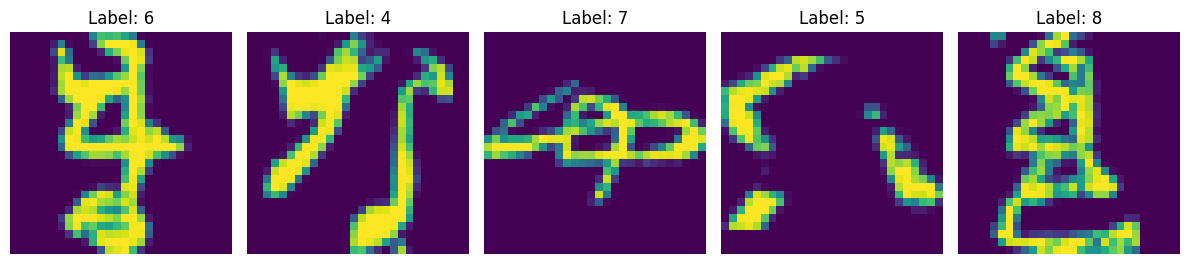


Number of Classes: 10


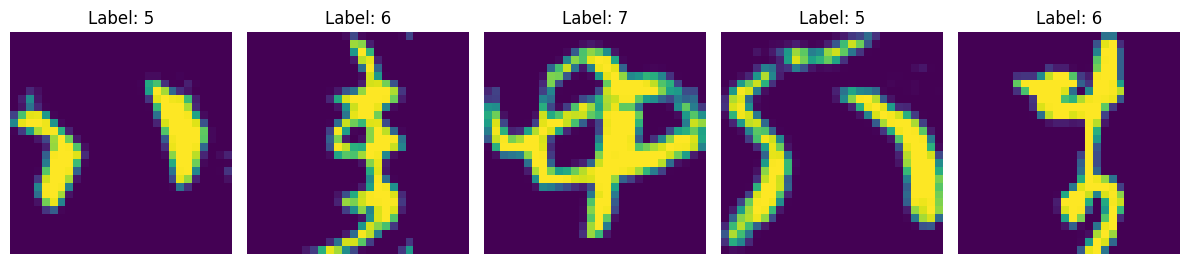


MODEL ARCHITECTURE
DeepQNN(
  (simam): SIMAM()
  (classical): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 236,258
Trainable Parameters : 236,258
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/132 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 2.1336 | Train Acc: 41.42% | Val Loss: 1.8447 | Val Acc: 47.78%


Epoch 2/25 [Train]:   0%|          | 0/132 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/132 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 0.0311 | Train Acc: 99.12% | Val Loss: 0.4943 | Val Acc: 91.39%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 80.54%

Sample Prediction
-----------------
True Label     : 2
Predicted Label: 3


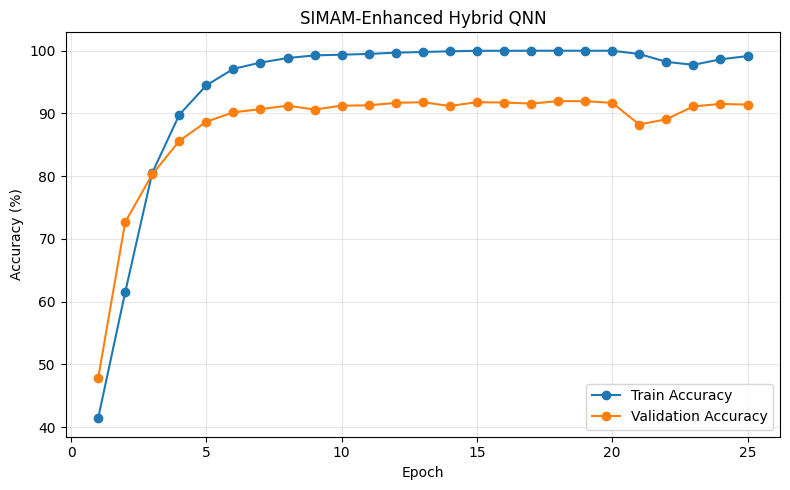

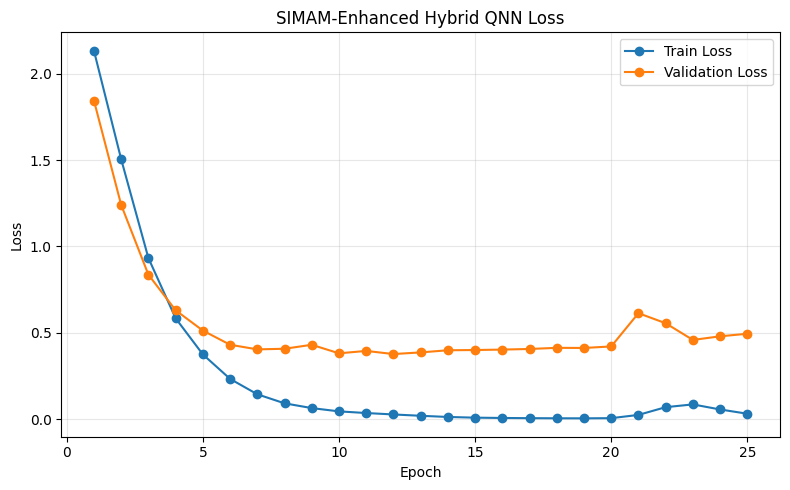

In [4]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

# ============================================================
# Dataset & Data Processing
# ============================================================

# ------------------------------------------------------------
# Dataset Fractions
# ------------------------------------------------------------

DATASET_FRACTION = 0.20

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
INTERNAL_TEST_FRACTION = 0.15


# ============================================================
# Transform
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    ),
])


# ============================================================
# Load Full FashionMNIST Training Dataset
# ============================================================

full_train_dataset = datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# ============================================================
# Load Official FashionMNIST Test Dataset
#
# IMPORTANT:
# This dataset is completely untouched.
# It is used ONLY for final evaluation.
# ============================================================

official_test_dataset = datasets.KMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Select 10% of Original Training Dataset
# ============================================================

total_train_samples = len(full_train_dataset)

selected_size = int(
    total_train_samples * DATASET_FRACTION
)


selected_dataset, _ = random_split(
    full_train_dataset,
    [
        selected_size,
        total_train_samples - selected_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Split Selected 10%
#
# 70% → Train
# 15% → Validation
# 15% → Internal Test
#
# Overall:
#
# 10% × 70% = 7%
# 10% × 15% = 1.5%
# 10% × 15% = 1.5%
# ============================================================

train_size = int(
    selected_size * TRAIN_FRACTION
)

val_size = int(
    selected_size * VAL_FRACTION
)

internal_test_size = (
    selected_size
    - train_size
    - val_size
)


train_dataset, val_dataset, internal_test_dataset = random_split(
    selected_dataset,
    [
        train_size,
        val_size,
        internal_test_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Dataset Information
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(
    f"Original FashionMNIST training dataset : "
    f"{total_train_samples:,}"
)

print(
    f"Selected dataset fraction               : "
    f"{DATASET_FRACTION * 100:.1f}%"
)

print(
    f"Selected samples                        : "
    f"{selected_size:,}"
)

print(
    f"Training samples                        : "
    f"{len(train_dataset):,} "
    f"({len(train_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Validation samples                      : "
    f"{len(val_dataset):,} "
    f"({len(val_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Internal test samples                   : "
    f"{len(internal_test_dataset):,} "
    f"({len(internal_test_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Official test samples                   : "
    f"{len(official_test_dataset):,}"
)

print("=" * 60)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Official FashionMNIST test set
test_loader = DataLoader(
    official_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Recover Original Indices
# ============================================================

selected_indices = selected_dataset.indices

train_indices = train_dataset.indices
val_indices = val_dataset.indices
internal_test_indices = internal_test_dataset.indices


train_original_indices = [
    selected_indices[i]
    for i in train_indices
]

val_original_indices = [
    selected_indices[i]
    for i in val_indices
]

internal_test_original_indices = [
    selected_indices[i]
    for i in internal_test_indices
]


# ============================================================
# Extract Labels
# ============================================================

train_labels = (
    full_train_dataset
    .targets[train_original_indices]
    .numpy()
)

val_labels = (
    full_train_dataset
    .targets[val_original_indices]
    .numpy()
)

internal_test_labels = (
    full_train_dataset
    .targets[internal_test_original_indices]
    .numpy()
)

official_test_labels = (
    official_test_dataset
    .targets
    .numpy()
)


# ============================================================
# Class Distribution
# ============================================================

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nValidation class distribution:")
print(Counter(val_labels))

print("\nInternal test class distribution:")
print(Counter(internal_test_labels))

print("\nOfficial test class distribution:")
print(Counter(official_test_labels))


# ============================================================
# Class Weights
# ============================================================
#
# IMPORTANT:
# Calculate class weights ONLY from training data.
# Do NOT use validation or test labels.
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)


print("\nClass Weights:")
print("-" * 30)

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# Number of Classes
# ============================================================

NUM_CLASSES = len(
    torch.unique(
        full_train_dataset.targets
    )
)

print(
    f"\nNumber of Classes: {NUM_CLASSES}"
)

# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(
        img,
        # cmap="gray"
    )

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

class DeepQNN(nn.Module):

    def __init__(self):

        super().__init__()


        # ====================================================
        # 1. SIMAM Attention
        # ====================================================

        self.simam = SIMAM(
            e_lambda=SIMAM_E_LAMBDA
        )


        # ====================================================
        # 2. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 784 → 256
            nn.Linear(
                784,
                256
            ),

            nn.ReLU(),


            # 256 → 128
            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            # 128 → NUM_QUBITS
            nn.Linear(
                128,
                NUM_QUBITS
            )

        )


        # ====================================================
        # 3. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer


        # ====================================================
        # 4. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # NUM_QUBITS → 64
            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.ReLU(),


            # 64 → 10
            nn.Linear(
                64,
                10
            )

        )


    # ========================================================
    # Forward Pass
    # ========================================================

    def forward(self, x):


        # ====================================================
        # STEP 1 — Input
        # ====================================================
        #
        # x:
        #
        # [B, 1, 28, 28]
        #
        # ====================================================


        # ====================================================
        # STEP 2 — SIMAM
        # ====================================================

        x = self.simam(x)


        # ====================================================
        # STEP 3 — Flatten
        # ====================================================
        #
        # [B, 1, 28, 28]
        #
        #        ↓
        #
        # [B, 784]
        #
        # ====================================================

        x = x.flatten(
            start_dim=1
        )


        # ====================================================
        # STEP 4 — Classical Feature Extraction
        # ====================================================
        #
        # 784 → 256 → 128 → NUM_QUBITS
        #
        # ====================================================

        x = self.classical(x)


        # ====================================================
        # STEP 5 — Bound Quantum Angles
        # ====================================================
        #
        # tanh:
        #
        # [-∞, +∞] → [-1, +1]
        #
        # × π:
        #
        # [-1, +1] → [-π, +π]
        #
        # ====================================================

        x = torch.tanh(x) * np.pi


        # ====================================================
        # STEP 6 — Quantum Circuit
        # ====================================================

        quantum_device = x.device


        # default.qubit runs on CPU
        x = self.quantum(
            x.cpu()
        )


        # Move quantum output back
        # to original device

        x = x.to(
            quantum_device
        )


        # ====================================================
        # STEP 7 — Classical Classifier
        # ====================================================
        #
        # NUM_QUBITS → 64 → 10
        #
        # ====================================================

        x = self.classifier(x)


        return x


# ============================================================
# Create Model
# ============================================================

model = DeepQNN().to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)

# ============================================================
# Predict One Official Test Sample
# ============================================================

image, label = official_test_dataset[0]

model.eval()

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(DEVICE)
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)

# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 42
Using device: cpu

DATASET INFORMATION
Original FashionMNIST training dataset : 60,000
Selected dataset fraction               : 30.0%
Selected samples                        : 18,000
Training samples                        : 12,600 (21.00% of original)
Validation samples                      : 2,700 (4.50% of original)
Internal test samples                   : 2,700 (4.50% of original)
Official test samples                   : 10,000

Training class distribution:
Counter({np.int64(6): 1319, np.int64(2): 1309, np.int64(7): 1289, np.int64(4): 1266, np.int64(9): 1245, np.int64(8): 1241, np.int64(1): 1238, np.int64(3): 1235, np.int64(5): 1234, np.int64(0): 1224})

Validation class distribution:
Counter({np.int64(9): 296, np.int64(2): 288, np.int64(6): 284, np.int64(4): 279, np.int64(7): 269, np.int64(0): 267, np.int64(8): 263, np.int64(3): 257, np.int64(5): 251, np.int64(1): 246})

Internal test class distribution:
Counter({np.int64(5): 296, np.int64(1): 292, np.int64(4): 2

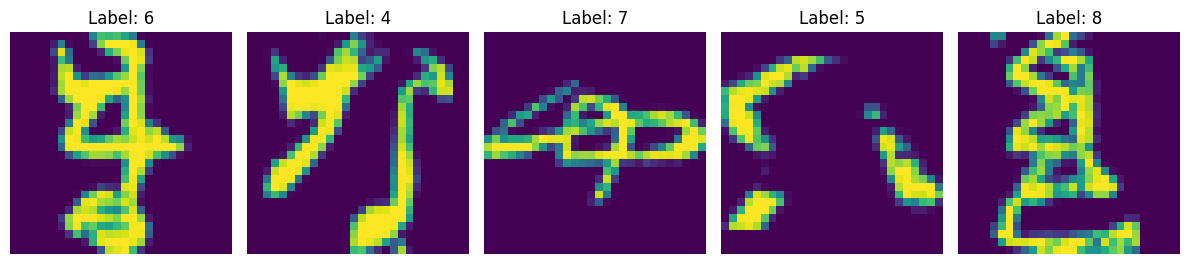


Number of Classes: 10


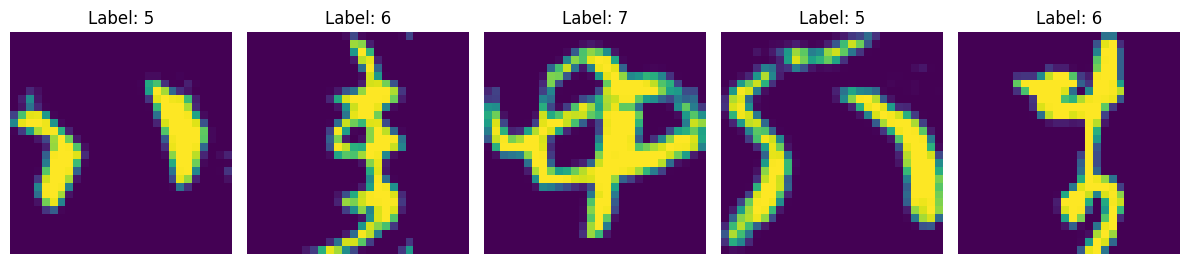


MODEL ARCHITECTURE
DeepQNN(
  (simam): SIMAM()
  (classical): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 236,258
Trainable Parameters : 236,258
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/197 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 1.9899 | Train Acc: 45.95% | Val Loss: 1.5060 | Val Acc: 62.11%


Epoch 2/25 [Train]:   0%|          | 0/197 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/197 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 0.0166 | Train Acc: 99.55% | Val Loss: 0.3934 | Val Acc: 93.56%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 83.72%

Sample Prediction
-----------------
True Label     : 2
Predicted Label: 5


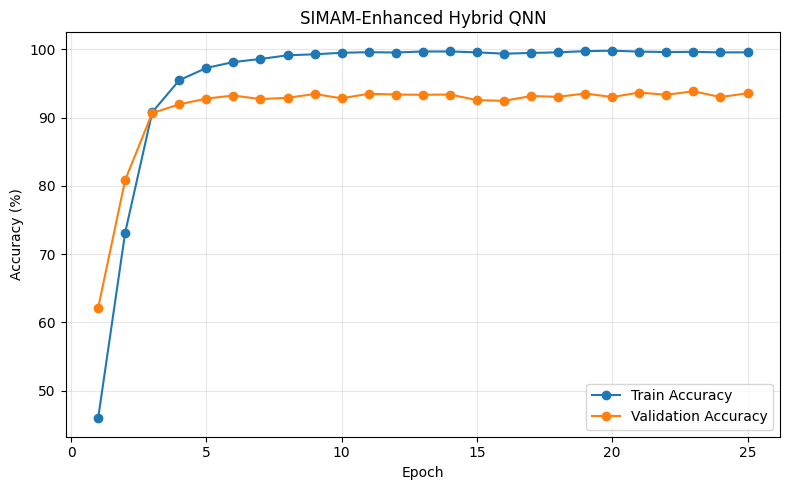

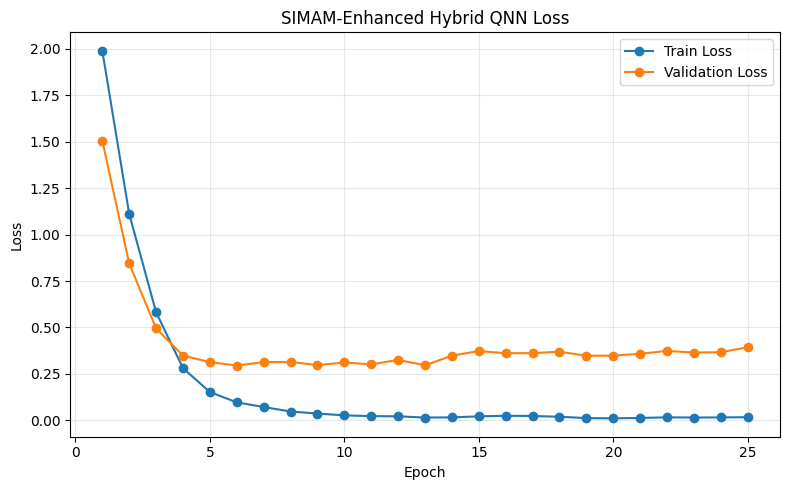

In [5]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

# ============================================================
# Dataset & Data Processing
# ============================================================

# ------------------------------------------------------------
# Dataset Fractions
# ------------------------------------------------------------

DATASET_FRACTION = 0.30

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
INTERNAL_TEST_FRACTION = 0.15


# ============================================================
# Transform
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    ),
])


# ============================================================
# Load Full FashionMNIST Training Dataset
# ============================================================

full_train_dataset = datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# ============================================================
# Load Official FashionMNIST Test Dataset
#
# IMPORTANT:
# This dataset is completely untouched.
# It is used ONLY for final evaluation.
# ============================================================

official_test_dataset = datasets.KMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Select 10% of Original Training Dataset
# ============================================================

total_train_samples = len(full_train_dataset)

selected_size = int(
    total_train_samples * DATASET_FRACTION
)


selected_dataset, _ = random_split(
    full_train_dataset,
    [
        selected_size,
        total_train_samples - selected_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Split Selected 10%
#
# 70% → Train
# 15% → Validation
# 15% → Internal Test
#
# Overall:
#
# 10% × 70% = 7%
# 10% × 15% = 1.5%
# 10% × 15% = 1.5%
# ============================================================

train_size = int(
    selected_size * TRAIN_FRACTION
)

val_size = int(
    selected_size * VAL_FRACTION
)

internal_test_size = (
    selected_size
    - train_size
    - val_size
)


train_dataset, val_dataset, internal_test_dataset = random_split(
    selected_dataset,
    [
        train_size,
        val_size,
        internal_test_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Dataset Information
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(
    f"Original FashionMNIST training dataset : "
    f"{total_train_samples:,}"
)

print(
    f"Selected dataset fraction               : "
    f"{DATASET_FRACTION * 100:.1f}%"
)

print(
    f"Selected samples                        : "
    f"{selected_size:,}"
)

print(
    f"Training samples                        : "
    f"{len(train_dataset):,} "
    f"({len(train_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Validation samples                      : "
    f"{len(val_dataset):,} "
    f"({len(val_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Internal test samples                   : "
    f"{len(internal_test_dataset):,} "
    f"({len(internal_test_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Official test samples                   : "
    f"{len(official_test_dataset):,}"
)

print("=" * 60)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Official FashionMNIST test set
test_loader = DataLoader(
    official_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Recover Original Indices
# ============================================================

selected_indices = selected_dataset.indices

train_indices = train_dataset.indices
val_indices = val_dataset.indices
internal_test_indices = internal_test_dataset.indices


train_original_indices = [
    selected_indices[i]
    for i in train_indices
]

val_original_indices = [
    selected_indices[i]
    for i in val_indices
]

internal_test_original_indices = [
    selected_indices[i]
    for i in internal_test_indices
]


# ============================================================
# Extract Labels
# ============================================================

train_labels = (
    full_train_dataset
    .targets[train_original_indices]
    .numpy()
)

val_labels = (
    full_train_dataset
    .targets[val_original_indices]
    .numpy()
)

internal_test_labels = (
    full_train_dataset
    .targets[internal_test_original_indices]
    .numpy()
)

official_test_labels = (
    official_test_dataset
    .targets
    .numpy()
)


# ============================================================
# Class Distribution
# ============================================================

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nValidation class distribution:")
print(Counter(val_labels))

print("\nInternal test class distribution:")
print(Counter(internal_test_labels))

print("\nOfficial test class distribution:")
print(Counter(official_test_labels))


# ============================================================
# Class Weights
# ============================================================
#
# IMPORTANT:
# Calculate class weights ONLY from training data.
# Do NOT use validation or test labels.
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)


print("\nClass Weights:")
print("-" * 30)

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# Number of Classes
# ============================================================

NUM_CLASSES = len(
    torch.unique(
        full_train_dataset.targets
    )
)

print(
    f"\nNumber of Classes: {NUM_CLASSES}"
)

# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(
        img,
        # cmap="gray"
    )

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

class DeepQNN(nn.Module):

    def __init__(self):

        super().__init__()


        # ====================================================
        # 1. SIMAM Attention
        # ====================================================

        self.simam = SIMAM(
            e_lambda=SIMAM_E_LAMBDA
        )


        # ====================================================
        # 2. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 784 → 256
            nn.Linear(
                784,
                256
            ),

            nn.ReLU(),


            # 256 → 128
            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            # 128 → NUM_QUBITS
            nn.Linear(
                128,
                NUM_QUBITS
            )

        )


        # ====================================================
        # 3. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer


        # ====================================================
        # 4. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # NUM_QUBITS → 64
            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.ReLU(),


            # 64 → 10
            nn.Linear(
                64,
                10
            )

        )


    # ========================================================
    # Forward Pass
    # ========================================================

    def forward(self, x):


        # ====================================================
        # STEP 1 — Input
        # ====================================================
        #
        # x:
        #
        # [B, 1, 28, 28]
        #
        # ====================================================


        # ====================================================
        # STEP 2 — SIMAM
        # ====================================================

        x = self.simam(x)


        # ====================================================
        # STEP 3 — Flatten
        # ====================================================
        #
        # [B, 1, 28, 28]
        #
        #        ↓
        #
        # [B, 784]
        #
        # ====================================================

        x = x.flatten(
            start_dim=1
        )


        # ====================================================
        # STEP 4 — Classical Feature Extraction
        # ====================================================
        #
        # 784 → 256 → 128 → NUM_QUBITS
        #
        # ====================================================

        x = self.classical(x)


        # ====================================================
        # STEP 5 — Bound Quantum Angles
        # ====================================================
        #
        # tanh:
        #
        # [-∞, +∞] → [-1, +1]
        #
        # × π:
        #
        # [-1, +1] → [-π, +π]
        #
        # ====================================================

        x = torch.tanh(x) * np.pi


        # ====================================================
        # STEP 6 — Quantum Circuit
        # ====================================================

        quantum_device = x.device


        # default.qubit runs on CPU
        x = self.quantum(
            x.cpu()
        )


        # Move quantum output back
        # to original device

        x = x.to(
            quantum_device
        )


        # ====================================================
        # STEP 7 — Classical Classifier
        # ====================================================
        #
        # NUM_QUBITS → 64 → 10
        #
        # ====================================================

        x = self.classifier(x)


        return x


# ============================================================
# Create Model
# ============================================================

model = DeepQNN().to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)

# ============================================================
# Predict One Official Test Sample
# ============================================================

image, label = official_test_dataset[0]

model.eval()

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(DEVICE)
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)

# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 42
Using device: cpu

DATASET INFORMATION
Original FashionMNIST training dataset : 60,000
Selected dataset fraction               : 40.0%
Selected samples                        : 24,000
Training samples                        : 16,800 (28.00% of original)
Validation samples                      : 3,600 (6.00% of original)
Internal test samples                   : 3,600 (6.00% of original)
Official test samples                   : 10,000

Training class distribution:
Counter({np.int64(6): 1738, np.int64(7): 1726, np.int64(4): 1722, np.int64(2): 1720, np.int64(8): 1701, np.int64(5): 1660, np.int64(9): 1653, np.int64(3): 1634, np.int64(0): 1627, np.int64(1): 1619})

Validation class distribution:
Counter({np.int64(9): 390, np.int64(0): 375, np.int64(2): 371, np.int64(6): 366, np.int64(4): 364, np.int64(1): 364, np.int64(5): 359, np.int64(7): 346, np.int64(8): 338, np.int64(3): 327})

Internal test class distribution:
Counter({np.int64(1): 386, np.int64(9): 380, np.int64(2): 3

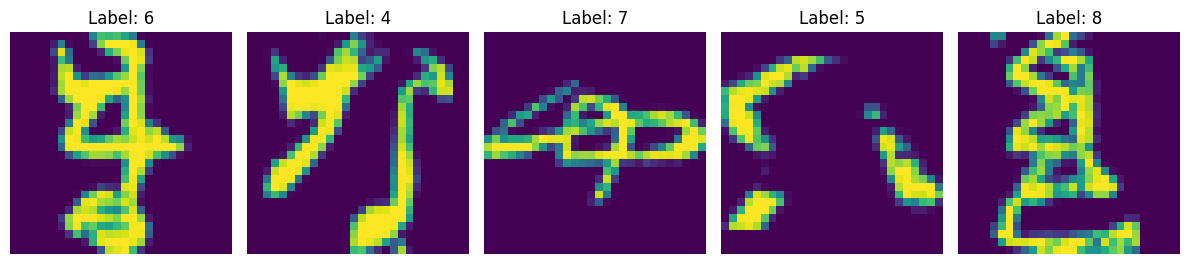


Number of Classes: 10


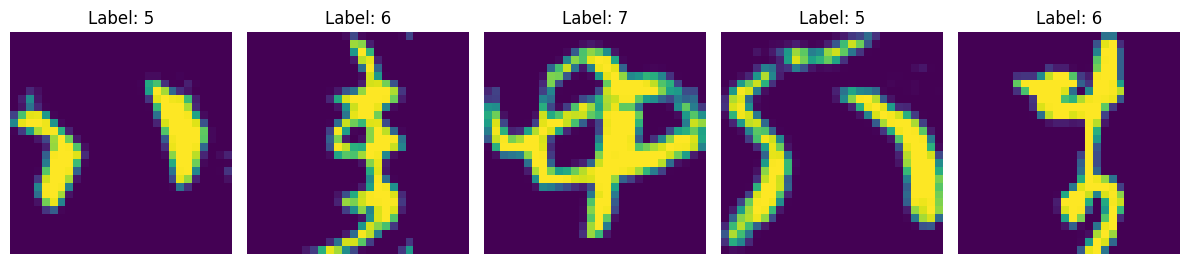


MODEL ARCHITECTURE
DeepQNN(
  (simam): SIMAM()
  (classical): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 236,258
Trainable Parameters : 236,258
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/263 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 1.8288 | Train Acc: 47.51% | Val Loss: 1.2652 | Val Acc: 59.67%


Epoch 2/25 [Train]:   0%|          | 0/263 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/263 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 0.0154 | Train Acc: 99.60% | Val Loss: 0.4347 | Val Acc: 94.19%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 85.50%

Sample Prediction
-----------------
True Label     : 2
Predicted Label: 9


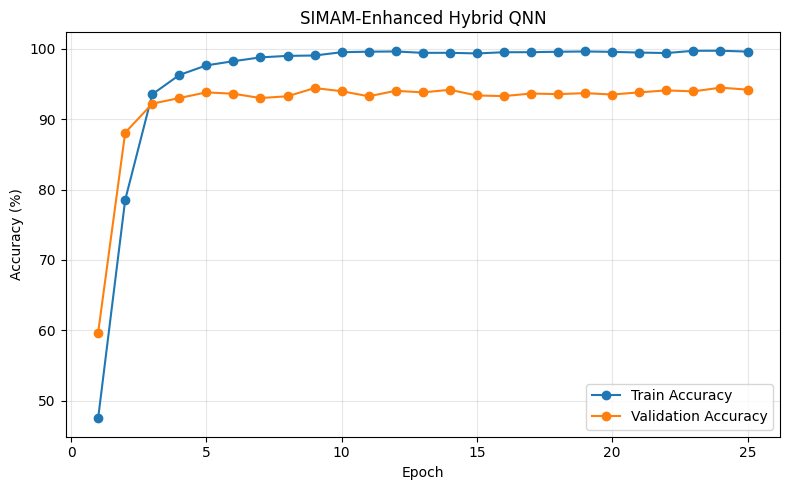

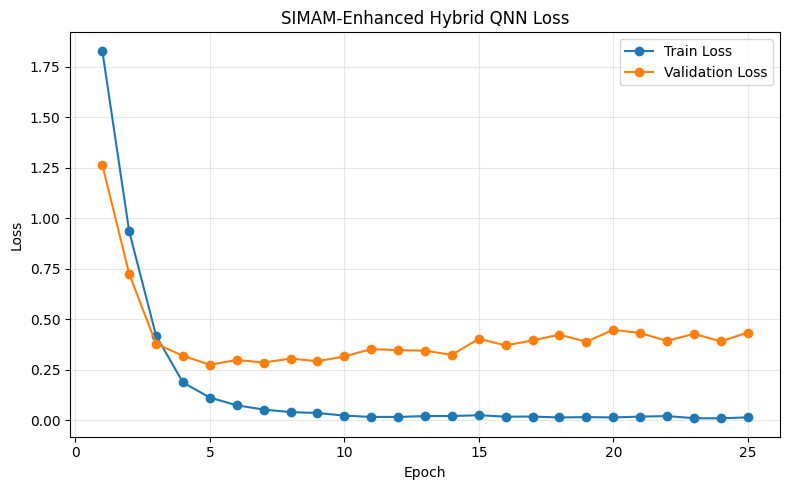

In [6]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

# ============================================================
# Dataset & Data Processing
# ============================================================

# ------------------------------------------------------------
# Dataset Fractions
# ------------------------------------------------------------

DATASET_FRACTION = 0.40

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
INTERNAL_TEST_FRACTION = 0.15


# ============================================================
# Transform
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    ),
])


# ============================================================
# Load Full FashionMNIST Training Dataset
# ============================================================

full_train_dataset = datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# ============================================================
# Load Official FashionMNIST Test Dataset
#
# IMPORTANT:
# This dataset is completely untouched.
# It is used ONLY for final evaluation.
# ============================================================

official_test_dataset = datasets.KMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Select 10% of Original Training Dataset
# ============================================================

total_train_samples = len(full_train_dataset)

selected_size = int(
    total_train_samples * DATASET_FRACTION
)


selected_dataset, _ = random_split(
    full_train_dataset,
    [
        selected_size,
        total_train_samples - selected_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Split Selected 10%
#
# 70% → Train
# 15% → Validation
# 15% → Internal Test
#
# Overall:
#
# 10% × 70% = 7%
# 10% × 15% = 1.5%
# 10% × 15% = 1.5%
# ============================================================

train_size = int(
    selected_size * TRAIN_FRACTION
)

val_size = int(
    selected_size * VAL_FRACTION
)

internal_test_size = (
    selected_size
    - train_size
    - val_size
)


train_dataset, val_dataset, internal_test_dataset = random_split(
    selected_dataset,
    [
        train_size,
        val_size,
        internal_test_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Dataset Information
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(
    f"Original FashionMNIST training dataset : "
    f"{total_train_samples:,}"
)

print(
    f"Selected dataset fraction               : "
    f"{DATASET_FRACTION * 100:.1f}%"
)

print(
    f"Selected samples                        : "
    f"{selected_size:,}"
)

print(
    f"Training samples                        : "
    f"{len(train_dataset):,} "
    f"({len(train_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Validation samples                      : "
    f"{len(val_dataset):,} "
    f"({len(val_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Internal test samples                   : "
    f"{len(internal_test_dataset):,} "
    f"({len(internal_test_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Official test samples                   : "
    f"{len(official_test_dataset):,}"
)

print("=" * 60)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Official FashionMNIST test set
test_loader = DataLoader(
    official_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Recover Original Indices
# ============================================================

selected_indices = selected_dataset.indices

train_indices = train_dataset.indices
val_indices = val_dataset.indices
internal_test_indices = internal_test_dataset.indices


train_original_indices = [
    selected_indices[i]
    for i in train_indices
]

val_original_indices = [
    selected_indices[i]
    for i in val_indices
]

internal_test_original_indices = [
    selected_indices[i]
    for i in internal_test_indices
]


# ============================================================
# Extract Labels
# ============================================================

train_labels = (
    full_train_dataset
    .targets[train_original_indices]
    .numpy()
)

val_labels = (
    full_train_dataset
    .targets[val_original_indices]
    .numpy()
)

internal_test_labels = (
    full_train_dataset
    .targets[internal_test_original_indices]
    .numpy()
)

official_test_labels = (
    official_test_dataset
    .targets
    .numpy()
)


# ============================================================
# Class Distribution
# ============================================================

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nValidation class distribution:")
print(Counter(val_labels))

print("\nInternal test class distribution:")
print(Counter(internal_test_labels))

print("\nOfficial test class distribution:")
print(Counter(official_test_labels))


# ============================================================
# Class Weights
# ============================================================
#
# IMPORTANT:
# Calculate class weights ONLY from training data.
# Do NOT use validation or test labels.
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)


print("\nClass Weights:")
print("-" * 30)

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# Number of Classes
# ============================================================

NUM_CLASSES = len(
    torch.unique(
        full_train_dataset.targets
    )
)

print(
    f"\nNumber of Classes: {NUM_CLASSES}"
)

# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(
        img,
        # cmap="gray"
    )

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

class DeepQNN(nn.Module):

    def __init__(self):

        super().__init__()


        # ====================================================
        # 1. SIMAM Attention
        # ====================================================

        self.simam = SIMAM(
            e_lambda=SIMAM_E_LAMBDA
        )


        # ====================================================
        # 2. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 784 → 256
            nn.Linear(
                784,
                256
            ),

            nn.ReLU(),


            # 256 → 128
            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            # 128 → NUM_QUBITS
            nn.Linear(
                128,
                NUM_QUBITS
            )

        )


        # ====================================================
        # 3. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer


        # ====================================================
        # 4. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # NUM_QUBITS → 64
            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.ReLU(),


            # 64 → 10
            nn.Linear(
                64,
                10
            )

        )


    # ========================================================
    # Forward Pass
    # ========================================================

    def forward(self, x):


        # ====================================================
        # STEP 1 — Input
        # ====================================================
        #
        # x:
        #
        # [B, 1, 28, 28]
        #
        # ====================================================


        # ====================================================
        # STEP 2 — SIMAM
        # ====================================================

        x = self.simam(x)


        # ====================================================
        # STEP 3 — Flatten
        # ====================================================
        #
        # [B, 1, 28, 28]
        #
        #        ↓
        #
        # [B, 784]
        #
        # ====================================================

        x = x.flatten(
            start_dim=1
        )


        # ====================================================
        # STEP 4 — Classical Feature Extraction
        # ====================================================
        #
        # 784 → 256 → 128 → NUM_QUBITS
        #
        # ====================================================

        x = self.classical(x)


        # ====================================================
        # STEP 5 — Bound Quantum Angles
        # ====================================================
        #
        # tanh:
        #
        # [-∞, +∞] → [-1, +1]
        #
        # × π:
        #
        # [-1, +1] → [-π, +π]
        #
        # ====================================================

        x = torch.tanh(x) * np.pi


        # ====================================================
        # STEP 6 — Quantum Circuit
        # ====================================================

        quantum_device = x.device


        # default.qubit runs on CPU
        x = self.quantum(
            x.cpu()
        )


        # Move quantum output back
        # to original device

        x = x.to(
            quantum_device
        )


        # ====================================================
        # STEP 7 — Classical Classifier
        # ====================================================
        #
        # NUM_QUBITS → 64 → 10
        #
        # ====================================================

        x = self.classifier(x)


        return x


# ============================================================
# Create Model
# ============================================================

model = DeepQNN().to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)

# ============================================================
# Predict One Official Test Sample
# ============================================================

image, label = official_test_dataset[0]

model.eval()

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(DEVICE)
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)

# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 42
Using device: cpu

DATASET INFORMATION
Original FashionMNIST training dataset : 60,000
Selected dataset fraction               : 50.0%
Selected samples                        : 30,000
Training samples                        : 21,000 (35.00% of original)
Validation samples                      : 4,500 (7.50% of original)
Internal test samples                   : 4,500 (7.50% of original)
Official test samples                   : 10,000

Training class distribution:
Counter({np.int64(2): 2181, np.int64(7): 2148, np.int64(4): 2142, np.int64(9): 2140, np.int64(5): 2103, np.int64(0): 2096, np.int64(6): 2093, np.int64(1): 2048, np.int64(8): 2044, np.int64(3): 2005})

Validation class distribution:
Counter({np.int64(6): 491, np.int64(3): 486, np.int64(0): 473, np.int64(1): 464, np.int64(8): 451, np.int64(7): 443, np.int64(9): 439, np.int64(5): 430, np.int64(4): 426, np.int64(2): 397})

Internal test class distribution:
Counter({np.int64(8): 487, np.int64(2): 469, np.int64(6): 4

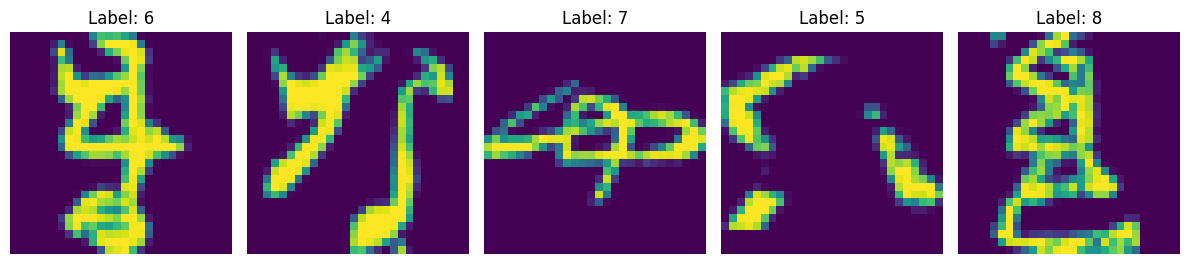


Number of Classes: 10


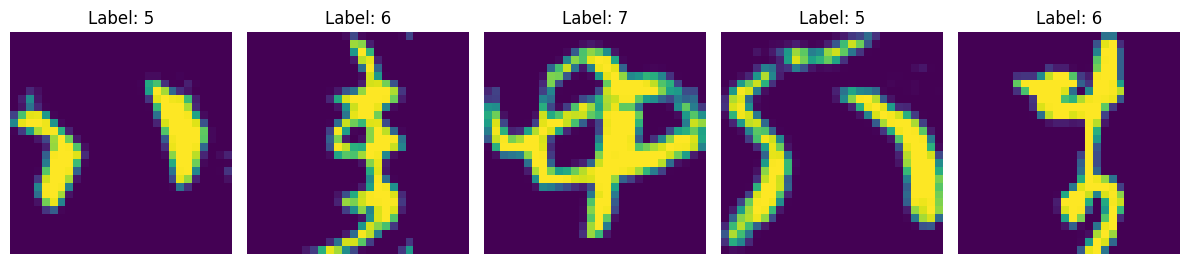


MODEL ARCHITECTURE
DeepQNN(
  (simam): SIMAM()
  (classical): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 236,258
Trainable Parameters : 236,258
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 1.6692 | Train Acc: 55.12% | Val Loss: 0.9803 | Val Acc: 75.11%


Epoch 2/25 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 0.0195 | Train Acc: 99.46% | Val Loss: 0.4356 | Val Acc: 93.49%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 86.64%

Sample Prediction
-----------------
True Label     : 2
Predicted Label: 5


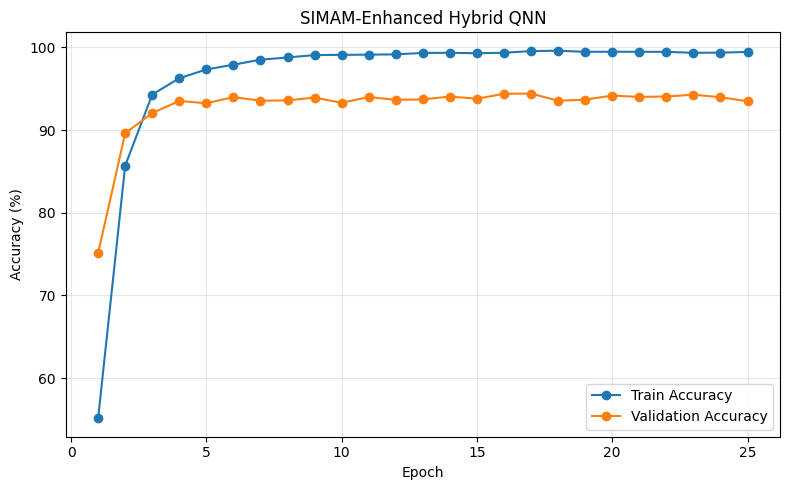

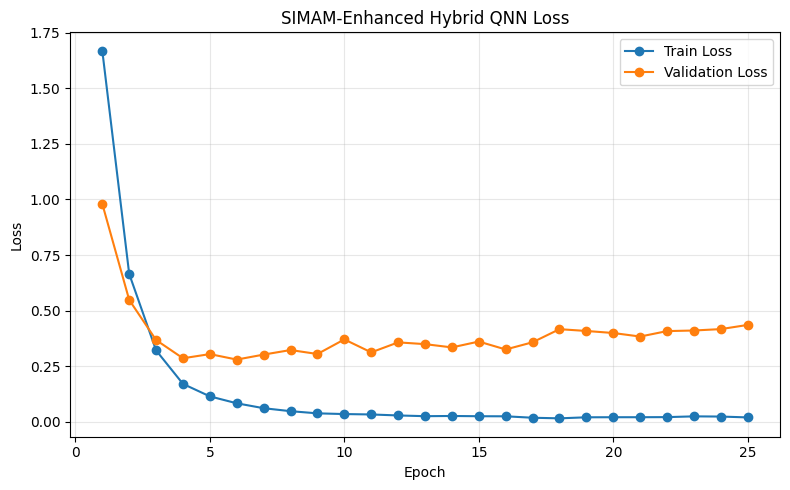

In [7]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

# ============================================================
# Dataset & Data Processing
# ============================================================

# ------------------------------------------------------------
# Dataset Fractions
# ------------------------------------------------------------

DATASET_FRACTION = 0.50

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
INTERNAL_TEST_FRACTION = 0.15


# ============================================================
# Transform
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    ),
])


# ============================================================
# Load Full FashionMNIST Training Dataset
# ============================================================

full_train_dataset = datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# ============================================================
# Load Official FashionMNIST Test Dataset
#
# IMPORTANT:
# This dataset is completely untouched.
# It is used ONLY for final evaluation.
# ============================================================

official_test_dataset = datasets.KMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Select 10% of Original Training Dataset
# ============================================================

total_train_samples = len(full_train_dataset)

selected_size = int(
    total_train_samples * DATASET_FRACTION
)


selected_dataset, _ = random_split(
    full_train_dataset,
    [
        selected_size,
        total_train_samples - selected_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Split Selected 10%
#
# 70% → Train
# 15% → Validation
# 15% → Internal Test
#
# Overall:
#
# 10% × 70% = 7%
# 10% × 15% = 1.5%
# 10% × 15% = 1.5%
# ============================================================

train_size = int(
    selected_size * TRAIN_FRACTION
)

val_size = int(
    selected_size * VAL_FRACTION
)

internal_test_size = (
    selected_size
    - train_size
    - val_size
)


train_dataset, val_dataset, internal_test_dataset = random_split(
    selected_dataset,
    [
        train_size,
        val_size,
        internal_test_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Dataset Information
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(
    f"Original FashionMNIST training dataset : "
    f"{total_train_samples:,}"
)

print(
    f"Selected dataset fraction               : "
    f"{DATASET_FRACTION * 100:.1f}%"
)

print(
    f"Selected samples                        : "
    f"{selected_size:,}"
)

print(
    f"Training samples                        : "
    f"{len(train_dataset):,} "
    f"({len(train_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Validation samples                      : "
    f"{len(val_dataset):,} "
    f"({len(val_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Internal test samples                   : "
    f"{len(internal_test_dataset):,} "
    f"({len(internal_test_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Official test samples                   : "
    f"{len(official_test_dataset):,}"
)

print("=" * 60)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Official FashionMNIST test set
test_loader = DataLoader(
    official_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Recover Original Indices
# ============================================================

selected_indices = selected_dataset.indices

train_indices = train_dataset.indices
val_indices = val_dataset.indices
internal_test_indices = internal_test_dataset.indices


train_original_indices = [
    selected_indices[i]
    for i in train_indices
]

val_original_indices = [
    selected_indices[i]
    for i in val_indices
]

internal_test_original_indices = [
    selected_indices[i]
    for i in internal_test_indices
]


# ============================================================
# Extract Labels
# ============================================================

train_labels = (
    full_train_dataset
    .targets[train_original_indices]
    .numpy()
)

val_labels = (
    full_train_dataset
    .targets[val_original_indices]
    .numpy()
)

internal_test_labels = (
    full_train_dataset
    .targets[internal_test_original_indices]
    .numpy()
)

official_test_labels = (
    official_test_dataset
    .targets
    .numpy()
)


# ============================================================
# Class Distribution
# ============================================================

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nValidation class distribution:")
print(Counter(val_labels))

print("\nInternal test class distribution:")
print(Counter(internal_test_labels))

print("\nOfficial test class distribution:")
print(Counter(official_test_labels))


# ============================================================
# Class Weights
# ============================================================
#
# IMPORTANT:
# Calculate class weights ONLY from training data.
# Do NOT use validation or test labels.
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)


print("\nClass Weights:")
print("-" * 30)

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# Number of Classes
# ============================================================

NUM_CLASSES = len(
    torch.unique(
        full_train_dataset.targets
    )
)

print(
    f"\nNumber of Classes: {NUM_CLASSES}"
)

# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(
        img,
        # cmap="gray"
    )

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

class DeepQNN(nn.Module):

    def __init__(self):

        super().__init__()


        # ====================================================
        # 1. SIMAM Attention
        # ====================================================

        self.simam = SIMAM(
            e_lambda=SIMAM_E_LAMBDA
        )


        # ====================================================
        # 2. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 784 → 256
            nn.Linear(
                784,
                256
            ),

            nn.ReLU(),


            # 256 → 128
            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            # 128 → NUM_QUBITS
            nn.Linear(
                128,
                NUM_QUBITS
            )

        )


        # ====================================================
        # 3. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer


        # ====================================================
        # 4. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # NUM_QUBITS → 64
            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.ReLU(),


            # 64 → 10
            nn.Linear(
                64,
                10
            )

        )


    # ========================================================
    # Forward Pass
    # ========================================================

    def forward(self, x):


        # ====================================================
        # STEP 1 — Input
        # ====================================================
        #
        # x:
        #
        # [B, 1, 28, 28]
        #
        # ====================================================


        # ====================================================
        # STEP 2 — SIMAM
        # ====================================================

        x = self.simam(x)


        # ====================================================
        # STEP 3 — Flatten
        # ====================================================
        #
        # [B, 1, 28, 28]
        #
        #        ↓
        #
        # [B, 784]
        #
        # ====================================================

        x = x.flatten(
            start_dim=1
        )


        # ====================================================
        # STEP 4 — Classical Feature Extraction
        # ====================================================
        #
        # 784 → 256 → 128 → NUM_QUBITS
        #
        # ====================================================

        x = self.classical(x)


        # ====================================================
        # STEP 5 — Bound Quantum Angles
        # ====================================================
        #
        # tanh:
        #
        # [-∞, +∞] → [-1, +1]
        #
        # × π:
        #
        # [-1, +1] → [-π, +π]
        #
        # ====================================================

        x = torch.tanh(x) * np.pi


        # ====================================================
        # STEP 6 — Quantum Circuit
        # ====================================================

        quantum_device = x.device


        # default.qubit runs on CPU
        x = self.quantum(
            x.cpu()
        )


        # Move quantum output back
        # to original device

        x = x.to(
            quantum_device
        )


        # ====================================================
        # STEP 7 — Classical Classifier
        # ====================================================
        #
        # NUM_QUBITS → 64 → 10
        #
        # ====================================================

        x = self.classifier(x)


        return x


# ============================================================
# Create Model
# ============================================================

model = DeepQNN().to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)

# ============================================================
# Predict One Official Test Sample
# ============================================================

image, label = official_test_dataset[0]

model.eval()

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(DEVICE)
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)

# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 42
Using device: cpu

DATASET INFORMATION
Original FashionMNIST training dataset : 60,000
Selected dataset fraction               : 60.0%
Selected samples                        : 36,000
Training samples                        : 25,200 (42.00% of original)
Validation samples                      : 5,400 (9.00% of original)
Internal test samples                   : 5,400 (9.00% of original)
Official test samples                   : 10,000

Training class distribution:
Counter({np.int64(6): 2556, np.int64(7): 2549, np.int64(4): 2548, np.int64(9): 2539, np.int64(1): 2523, np.int64(0): 2513, np.int64(3): 2510, np.int64(8): 2501, np.int64(5): 2491, np.int64(2): 2470})

Validation class distribution:
Counter({np.int64(2): 562, np.int64(0): 557, np.int64(6): 556, np.int64(8): 555, np.int64(1): 541, np.int64(7): 533, np.int64(5): 532, np.int64(4): 527, np.int64(9): 523, np.int64(3): 514})

Internal test class distribution:
Counter({np.int64(2): 596, np.int64(0): 553, np.int64(6): 5

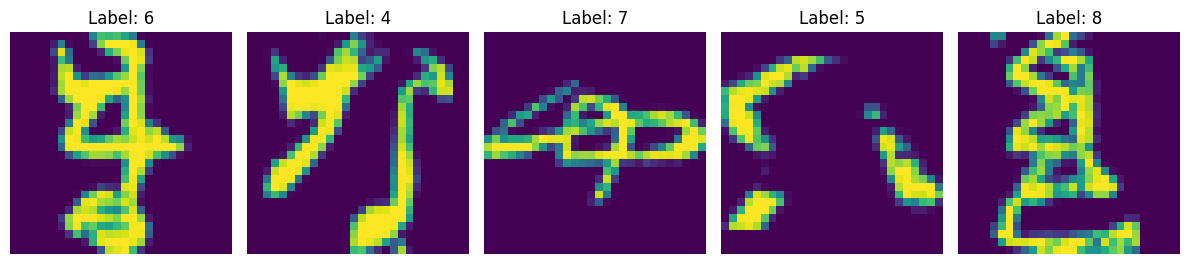


Number of Classes: 10


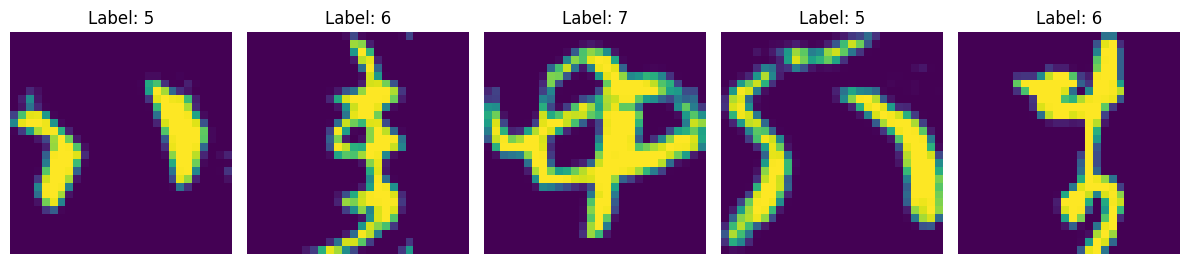


MODEL ARCHITECTURE
DeepQNN(
  (simam): SIMAM()
  (classical): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 236,258
Trainable Parameters : 236,258
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/85 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 1.5726 | Train Acc: 53.66% | Val Loss: 0.9647 | Val Acc: 76.50%


Epoch 2/25 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/85 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 0.0208 | Train Acc: 99.46% | Val Loss: 0.4344 | Val Acc: 94.24%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 87.87%

Sample Prediction
-----------------
True Label     : 2
Predicted Label: 2


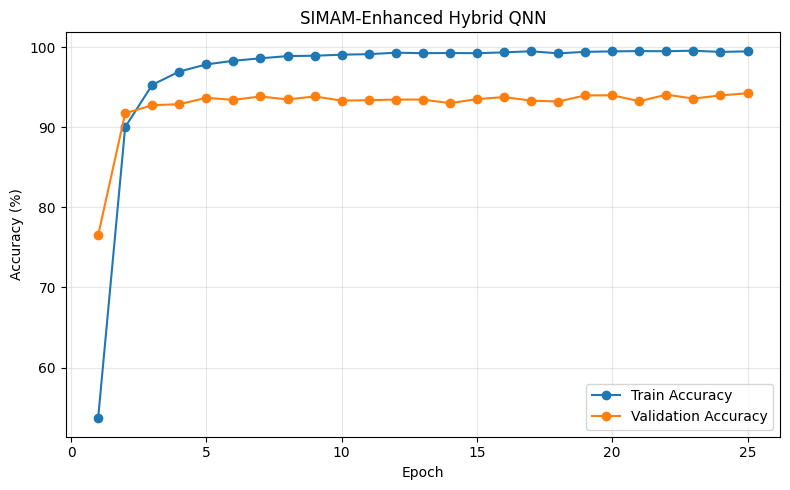

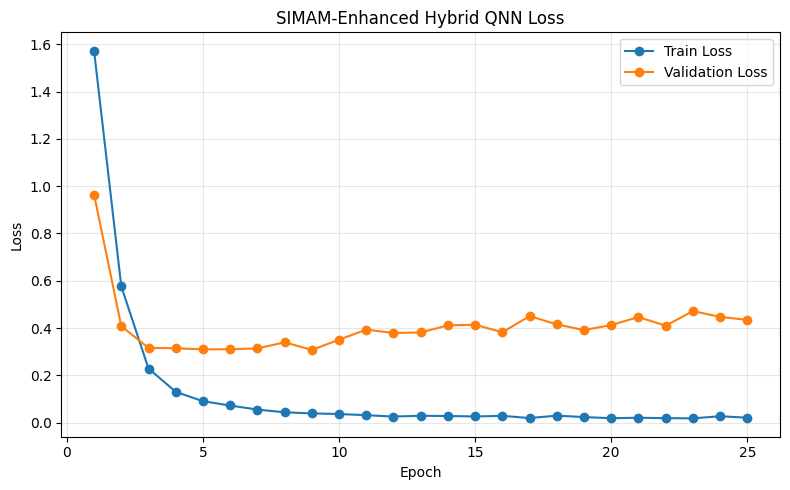

In [8]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

# ============================================================
# Dataset & Data Processing
# ============================================================

# ------------------------------------------------------------
# Dataset Fractions
# ------------------------------------------------------------

DATASET_FRACTION = 0.60

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
INTERNAL_TEST_FRACTION = 0.15


# ============================================================
# Transform
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    ),
])


# ============================================================
# Load Full FashionMNIST Training Dataset
# ============================================================

full_train_dataset = datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# ============================================================
# Load Official FashionMNIST Test Dataset
#
# IMPORTANT:
# This dataset is completely untouched.
# It is used ONLY for final evaluation.
# ============================================================

official_test_dataset = datasets.KMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Select 10% of Original Training Dataset
# ============================================================

total_train_samples = len(full_train_dataset)

selected_size = int(
    total_train_samples * DATASET_FRACTION
)


selected_dataset, _ = random_split(
    full_train_dataset,
    [
        selected_size,
        total_train_samples - selected_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Split Selected 10%
#
# 70% → Train
# 15% → Validation
# 15% → Internal Test
#
# Overall:
#
# 10% × 70% = 7%
# 10% × 15% = 1.5%
# 10% × 15% = 1.5%
# ============================================================

train_size = int(
    selected_size * TRAIN_FRACTION
)

val_size = int(
    selected_size * VAL_FRACTION
)

internal_test_size = (
    selected_size
    - train_size
    - val_size
)


train_dataset, val_dataset, internal_test_dataset = random_split(
    selected_dataset,
    [
        train_size,
        val_size,
        internal_test_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Dataset Information
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(
    f"Original FashionMNIST training dataset : "
    f"{total_train_samples:,}"
)

print(
    f"Selected dataset fraction               : "
    f"{DATASET_FRACTION * 100:.1f}%"
)

print(
    f"Selected samples                        : "
    f"{selected_size:,}"
)

print(
    f"Training samples                        : "
    f"{len(train_dataset):,} "
    f"({len(train_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Validation samples                      : "
    f"{len(val_dataset):,} "
    f"({len(val_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Internal test samples                   : "
    f"{len(internal_test_dataset):,} "
    f"({len(internal_test_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Official test samples                   : "
    f"{len(official_test_dataset):,}"
)

print("=" * 60)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Official FashionMNIST test set
test_loader = DataLoader(
    official_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Recover Original Indices
# ============================================================

selected_indices = selected_dataset.indices

train_indices = train_dataset.indices
val_indices = val_dataset.indices
internal_test_indices = internal_test_dataset.indices


train_original_indices = [
    selected_indices[i]
    for i in train_indices
]

val_original_indices = [
    selected_indices[i]
    for i in val_indices
]

internal_test_original_indices = [
    selected_indices[i]
    for i in internal_test_indices
]


# ============================================================
# Extract Labels
# ============================================================

train_labels = (
    full_train_dataset
    .targets[train_original_indices]
    .numpy()
)

val_labels = (
    full_train_dataset
    .targets[val_original_indices]
    .numpy()
)

internal_test_labels = (
    full_train_dataset
    .targets[internal_test_original_indices]
    .numpy()
)

official_test_labels = (
    official_test_dataset
    .targets
    .numpy()
)


# ============================================================
# Class Distribution
# ============================================================

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nValidation class distribution:")
print(Counter(val_labels))

print("\nInternal test class distribution:")
print(Counter(internal_test_labels))

print("\nOfficial test class distribution:")
print(Counter(official_test_labels))


# ============================================================
# Class Weights
# ============================================================
#
# IMPORTANT:
# Calculate class weights ONLY from training data.
# Do NOT use validation or test labels.
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)


print("\nClass Weights:")
print("-" * 30)

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# Number of Classes
# ============================================================

NUM_CLASSES = len(
    torch.unique(
        full_train_dataset.targets
    )
)

print(
    f"\nNumber of Classes: {NUM_CLASSES}"
)

# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(
        img,
        # cmap="gray"
    )

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

class DeepQNN(nn.Module):

    def __init__(self):

        super().__init__()


        # ====================================================
        # 1. SIMAM Attention
        # ====================================================

        self.simam = SIMAM(
            e_lambda=SIMAM_E_LAMBDA
        )


        # ====================================================
        # 2. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 784 → 256
            nn.Linear(
                784,
                256
            ),

            nn.ReLU(),


            # 256 → 128
            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            # 128 → NUM_QUBITS
            nn.Linear(
                128,
                NUM_QUBITS
            )

        )


        # ====================================================
        # 3. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer


        # ====================================================
        # 4. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # NUM_QUBITS → 64
            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.ReLU(),


            # 64 → 10
            nn.Linear(
                64,
                10
            )

        )


    # ========================================================
    # Forward Pass
    # ========================================================

    def forward(self, x):


        # ====================================================
        # STEP 1 — Input
        # ====================================================
        #
        # x:
        #
        # [B, 1, 28, 28]
        #
        # ====================================================


        # ====================================================
        # STEP 2 — SIMAM
        # ====================================================

        x = self.simam(x)


        # ====================================================
        # STEP 3 — Flatten
        # ====================================================
        #
        # [B, 1, 28, 28]
        #
        #        ↓
        #
        # [B, 784]
        #
        # ====================================================

        x = x.flatten(
            start_dim=1
        )


        # ====================================================
        # STEP 4 — Classical Feature Extraction
        # ====================================================
        #
        # 784 → 256 → 128 → NUM_QUBITS
        #
        # ====================================================

        x = self.classical(x)


        # ====================================================
        # STEP 5 — Bound Quantum Angles
        # ====================================================
        #
        # tanh:
        #
        # [-∞, +∞] → [-1, +1]
        #
        # × π:
        #
        # [-1, +1] → [-π, +π]
        #
        # ====================================================

        x = torch.tanh(x) * np.pi


        # ====================================================
        # STEP 6 — Quantum Circuit
        # ====================================================

        quantum_device = x.device


        # default.qubit runs on CPU
        x = self.quantum(
            x.cpu()
        )


        # Move quantum output back
        # to original device

        x = x.to(
            quantum_device
        )


        # ====================================================
        # STEP 7 — Classical Classifier
        # ====================================================
        #
        # NUM_QUBITS → 64 → 10
        #
        # ====================================================

        x = self.classifier(x)


        return x


# ============================================================
# Create Model
# ============================================================

model = DeepQNN().to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)

# ============================================================
# Predict One Official Test Sample
# ============================================================

image, label = official_test_dataset[0]

model.eval()

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(DEVICE)
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)

# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 42
Using device: cpu

DATASET INFORMATION
Original FashionMNIST training dataset : 60,000
Selected dataset fraction               : 70.0%
Selected samples                        : 42,000
Training samples                        : 29,399 (49.00% of original)
Validation samples                      : 6,300 (10.50% of original)
Internal test samples                   : 6,301 (10.50% of original)
Official test samples                   : 10,000

Training class distribution:
Counter({np.int64(7): 3006, np.int64(0): 2964, np.int64(2): 2963, np.int64(4): 2960, np.int64(5): 2933, np.int64(6): 2930, np.int64(9): 2928, np.int64(1): 2920, np.int64(3): 2902, np.int64(8): 2893})

Validation class distribution:
Counter({np.int64(9): 649, np.int64(5): 643, np.int64(6): 641, np.int64(3): 636, np.int64(0): 635, np.int64(4): 633, np.int64(8): 625, np.int64(2): 622, np.int64(1): 621, np.int64(7): 595})

Internal test class distribution:
Counter({np.int64(7): 663, np.int64(6): 662, np.int64(2):

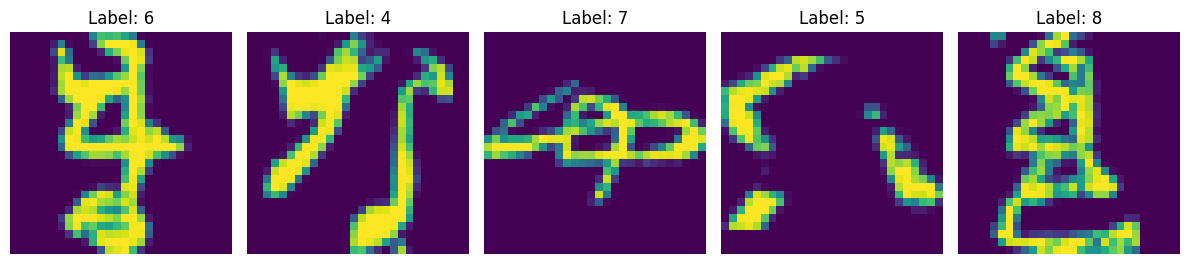


Number of Classes: 10


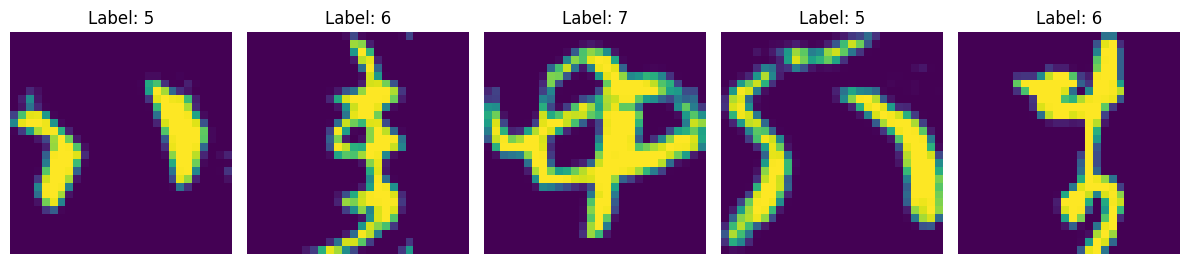


MODEL ARCHITECTURE
DeepQNN(
  (simam): SIMAM()
  (classical): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 236,258
Trainable Parameters : 236,258
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/460 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 1.4416 | Train Acc: 64.07% | Val Loss: 0.7207 | Val Acc: 79.37%


Epoch 2/25 [Train]:   0%|          | 0/460 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/460 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 0.0226 | Train Acc: 99.43% | Val Loss: 0.3414 | Val Acc: 94.79%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 88.44%

Sample Prediction
-----------------
True Label     : 2
Predicted Label: 2


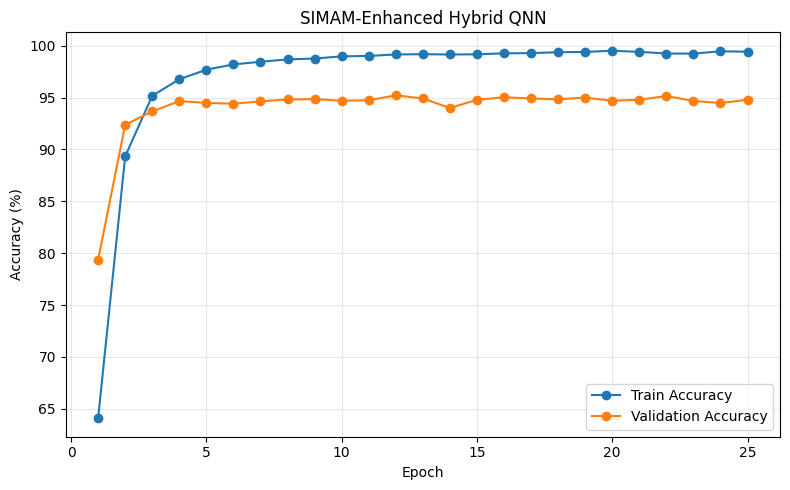

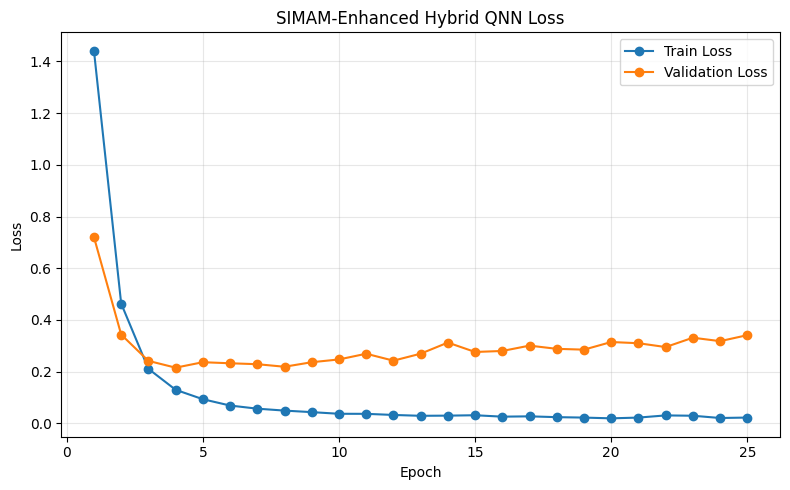

In [9]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

# ============================================================
# Dataset & Data Processing
# ============================================================

# ------------------------------------------------------------
# Dataset Fractions
# ------------------------------------------------------------

DATASET_FRACTION = 0.70

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
INTERNAL_TEST_FRACTION = 0.15


# ============================================================
# Transform
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    ),
])


# ============================================================
# Load Full FashionMNIST Training Dataset
# ============================================================

full_train_dataset = datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# ============================================================
# Load Official FashionMNIST Test Dataset
#
# IMPORTANT:
# This dataset is completely untouched.
# It is used ONLY for final evaluation.
# ============================================================

official_test_dataset = datasets.KMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Select 10% of Original Training Dataset
# ============================================================

total_train_samples = len(full_train_dataset)

selected_size = int(
    total_train_samples * DATASET_FRACTION
)


selected_dataset, _ = random_split(
    full_train_dataset,
    [
        selected_size,
        total_train_samples - selected_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Split Selected 10%
#
# 70% → Train
# 15% → Validation
# 15% → Internal Test
#
# Overall:
#
# 10% × 70% = 7%
# 10% × 15% = 1.5%
# 10% × 15% = 1.5%
# ============================================================

train_size = int(
    selected_size * TRAIN_FRACTION
)

val_size = int(
    selected_size * VAL_FRACTION
)

internal_test_size = (
    selected_size
    - train_size
    - val_size
)


train_dataset, val_dataset, internal_test_dataset = random_split(
    selected_dataset,
    [
        train_size,
        val_size,
        internal_test_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Dataset Information
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(
    f"Original FashionMNIST training dataset : "
    f"{total_train_samples:,}"
)

print(
    f"Selected dataset fraction               : "
    f"{DATASET_FRACTION * 100:.1f}%"
)

print(
    f"Selected samples                        : "
    f"{selected_size:,}"
)

print(
    f"Training samples                        : "
    f"{len(train_dataset):,} "
    f"({len(train_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Validation samples                      : "
    f"{len(val_dataset):,} "
    f"({len(val_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Internal test samples                   : "
    f"{len(internal_test_dataset):,} "
    f"({len(internal_test_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Official test samples                   : "
    f"{len(official_test_dataset):,}"
)

print("=" * 60)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Official FashionMNIST test set
test_loader = DataLoader(
    official_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Recover Original Indices
# ============================================================

selected_indices = selected_dataset.indices

train_indices = train_dataset.indices
val_indices = val_dataset.indices
internal_test_indices = internal_test_dataset.indices


train_original_indices = [
    selected_indices[i]
    for i in train_indices
]

val_original_indices = [
    selected_indices[i]
    for i in val_indices
]

internal_test_original_indices = [
    selected_indices[i]
    for i in internal_test_indices
]


# ============================================================
# Extract Labels
# ============================================================

train_labels = (
    full_train_dataset
    .targets[train_original_indices]
    .numpy()
)

val_labels = (
    full_train_dataset
    .targets[val_original_indices]
    .numpy()
)

internal_test_labels = (
    full_train_dataset
    .targets[internal_test_original_indices]
    .numpy()
)

official_test_labels = (
    official_test_dataset
    .targets
    .numpy()
)


# ============================================================
# Class Distribution
# ============================================================

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nValidation class distribution:")
print(Counter(val_labels))

print("\nInternal test class distribution:")
print(Counter(internal_test_labels))

print("\nOfficial test class distribution:")
print(Counter(official_test_labels))


# ============================================================
# Class Weights
# ============================================================
#
# IMPORTANT:
# Calculate class weights ONLY from training data.
# Do NOT use validation or test labels.
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)


print("\nClass Weights:")
print("-" * 30)

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# Number of Classes
# ============================================================

NUM_CLASSES = len(
    torch.unique(
        full_train_dataset.targets
    )
)

print(
    f"\nNumber of Classes: {NUM_CLASSES}"
)

# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(
        img,
        # cmap="gray"
    )

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

class DeepQNN(nn.Module):

    def __init__(self):

        super().__init__()


        # ====================================================
        # 1. SIMAM Attention
        # ====================================================

        self.simam = SIMAM(
            e_lambda=SIMAM_E_LAMBDA
        )


        # ====================================================
        # 2. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 784 → 256
            nn.Linear(
                784,
                256
            ),

            nn.ReLU(),


            # 256 → 128
            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            # 128 → NUM_QUBITS
            nn.Linear(
                128,
                NUM_QUBITS
            )

        )


        # ====================================================
        # 3. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer


        # ====================================================
        # 4. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # NUM_QUBITS → 64
            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.ReLU(),


            # 64 → 10
            nn.Linear(
                64,
                10
            )

        )


    # ========================================================
    # Forward Pass
    # ========================================================

    def forward(self, x):


        # ====================================================
        # STEP 1 — Input
        # ====================================================
        #
        # x:
        #
        # [B, 1, 28, 28]
        #
        # ====================================================


        # ====================================================
        # STEP 2 — SIMAM
        # ====================================================

        x = self.simam(x)


        # ====================================================
        # STEP 3 — Flatten
        # ====================================================
        #
        # [B, 1, 28, 28]
        #
        #        ↓
        #
        # [B, 784]
        #
        # ====================================================

        x = x.flatten(
            start_dim=1
        )


        # ====================================================
        # STEP 4 — Classical Feature Extraction
        # ====================================================
        #
        # 784 → 256 → 128 → NUM_QUBITS
        #
        # ====================================================

        x = self.classical(x)


        # ====================================================
        # STEP 5 — Bound Quantum Angles
        # ====================================================
        #
        # tanh:
        #
        # [-∞, +∞] → [-1, +1]
        #
        # × π:
        #
        # [-1, +1] → [-π, +π]
        #
        # ====================================================

        x = torch.tanh(x) * np.pi


        # ====================================================
        # STEP 6 — Quantum Circuit
        # ====================================================

        quantum_device = x.device


        # default.qubit runs on CPU
        x = self.quantum(
            x.cpu()
        )


        # Move quantum output back
        # to original device

        x = x.to(
            quantum_device
        )


        # ====================================================
        # STEP 7 — Classical Classifier
        # ====================================================
        #
        # NUM_QUBITS → 64 → 10
        #
        # ====================================================

        x = self.classifier(x)


        return x


# ============================================================
# Create Model
# ============================================================

model = DeepQNN().to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)

# ============================================================
# Predict One Official Test Sample
# ============================================================

image, label = official_test_dataset[0]

model.eval()

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(DEVICE)
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)

# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 42
Using device: cpu

DATASET INFORMATION
Original FashionMNIST training dataset : 60,000
Selected dataset fraction               : 80.0%
Selected samples                        : 48,000
Training samples                        : 33,600 (56.00% of original)
Validation samples                      : 7,200 (12.00% of original)
Internal test samples                   : 7,200 (12.00% of original)
Official test samples                   : 10,000

Training class distribution:
Counter({np.int64(7): 3404, np.int64(0): 3404, np.int64(1): 3393, np.int64(6): 3392, np.int64(8): 3370, np.int64(5): 3358, np.int64(4): 3331, np.int64(3): 3322, np.int64(2): 3317, np.int64(9): 3309})

Validation class distribution:
Counter({np.int64(4): 770, np.int64(8): 747, np.int64(9): 737, np.int64(3): 732, np.int64(2): 731, np.int64(7): 720, np.int64(1): 702, np.int64(6): 699, np.int64(5): 682, np.int64(0): 680})

Internal test class distribution:
Counter({np.int64(2): 766, np.int64(5): 756, np.int64(6):

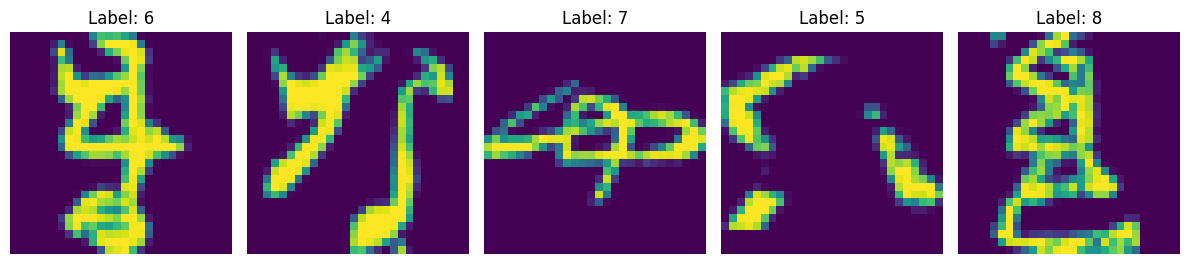


Number of Classes: 10


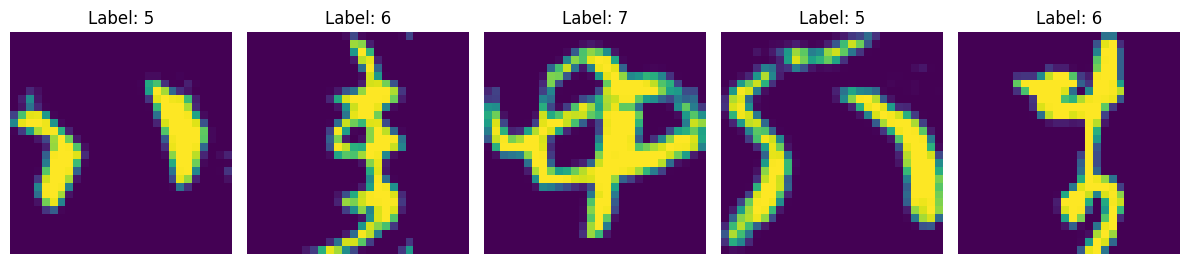


MODEL ARCHITECTURE
DeepQNN(
  (simam): SIMAM()
  (classical): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 236,258
Trainable Parameters : 236,258
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/525 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 1.4193 | Train Acc: 59.86% | Val Loss: 0.7350 | Val Acc: 87.85%


Epoch 2/25 [Train]:   0%|          | 0/525 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/525 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 0.0193 | Train Acc: 99.54% | Val Loss: 0.3272 | Val Acc: 95.51%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 89.60%

Sample Prediction
-----------------
True Label     : 2
Predicted Label: 2


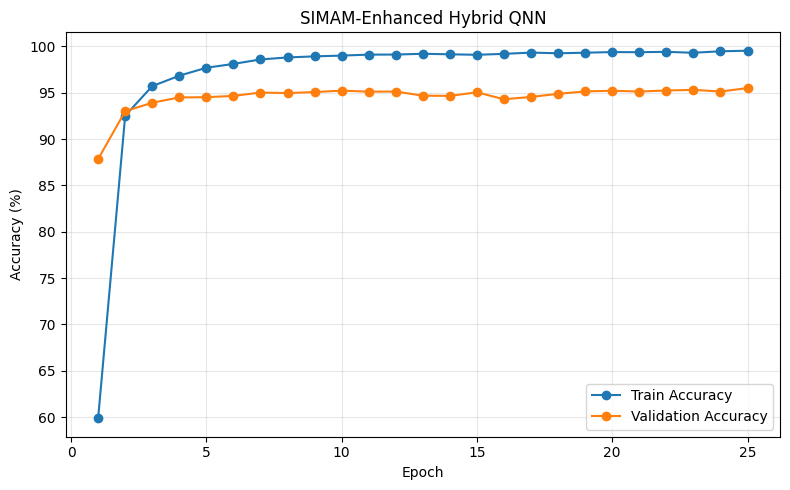

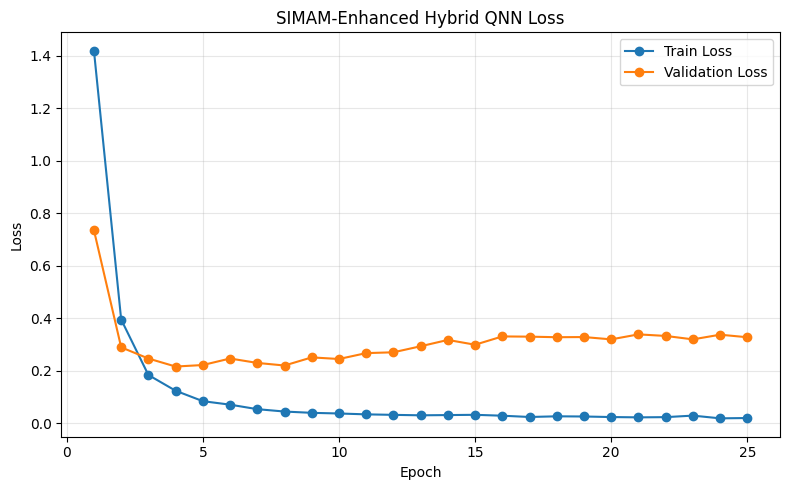

In [10]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

# ============================================================
# Dataset & Data Processing
# ============================================================

# ------------------------------------------------------------
# Dataset Fractions
# ------------------------------------------------------------

DATASET_FRACTION = 0.80

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
INTERNAL_TEST_FRACTION = 0.15


# ============================================================
# Transform
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    ),
])


# ============================================================
# Load Full FashionMNIST Training Dataset
# ============================================================

full_train_dataset = datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# ============================================================
# Load Official FashionMNIST Test Dataset
#
# IMPORTANT:
# This dataset is completely untouched.
# It is used ONLY for final evaluation.
# ============================================================

official_test_dataset = datasets.KMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Select 10% of Original Training Dataset
# ============================================================

total_train_samples = len(full_train_dataset)

selected_size = int(
    total_train_samples * DATASET_FRACTION
)


selected_dataset, _ = random_split(
    full_train_dataset,
    [
        selected_size,
        total_train_samples - selected_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Split Selected 10%
#
# 70% → Train
# 15% → Validation
# 15% → Internal Test
#
# Overall:
#
# 10% × 70% = 7%
# 10% × 15% = 1.5%
# 10% × 15% = 1.5%
# ============================================================

train_size = int(
    selected_size * TRAIN_FRACTION
)

val_size = int(
    selected_size * VAL_FRACTION
)

internal_test_size = (
    selected_size
    - train_size
    - val_size
)


train_dataset, val_dataset, internal_test_dataset = random_split(
    selected_dataset,
    [
        train_size,
        val_size,
        internal_test_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Dataset Information
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(
    f"Original FashionMNIST training dataset : "
    f"{total_train_samples:,}"
)

print(
    f"Selected dataset fraction               : "
    f"{DATASET_FRACTION * 100:.1f}%"
)

print(
    f"Selected samples                        : "
    f"{selected_size:,}"
)

print(
    f"Training samples                        : "
    f"{len(train_dataset):,} "
    f"({len(train_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Validation samples                      : "
    f"{len(val_dataset):,} "
    f"({len(val_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Internal test samples                   : "
    f"{len(internal_test_dataset):,} "
    f"({len(internal_test_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Official test samples                   : "
    f"{len(official_test_dataset):,}"
)

print("=" * 60)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Official FashionMNIST test set
test_loader = DataLoader(
    official_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Recover Original Indices
# ============================================================

selected_indices = selected_dataset.indices

train_indices = train_dataset.indices
val_indices = val_dataset.indices
internal_test_indices = internal_test_dataset.indices


train_original_indices = [
    selected_indices[i]
    for i in train_indices
]

val_original_indices = [
    selected_indices[i]
    for i in val_indices
]

internal_test_original_indices = [
    selected_indices[i]
    for i in internal_test_indices
]


# ============================================================
# Extract Labels
# ============================================================

train_labels = (
    full_train_dataset
    .targets[train_original_indices]
    .numpy()
)

val_labels = (
    full_train_dataset
    .targets[val_original_indices]
    .numpy()
)

internal_test_labels = (
    full_train_dataset
    .targets[internal_test_original_indices]
    .numpy()
)

official_test_labels = (
    official_test_dataset
    .targets
    .numpy()
)


# ============================================================
# Class Distribution
# ============================================================

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nValidation class distribution:")
print(Counter(val_labels))

print("\nInternal test class distribution:")
print(Counter(internal_test_labels))

print("\nOfficial test class distribution:")
print(Counter(official_test_labels))


# ============================================================
# Class Weights
# ============================================================
#
# IMPORTANT:
# Calculate class weights ONLY from training data.
# Do NOT use validation or test labels.
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)


print("\nClass Weights:")
print("-" * 30)

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# Number of Classes
# ============================================================

NUM_CLASSES = len(
    torch.unique(
        full_train_dataset.targets
    )
)

print(
    f"\nNumber of Classes: {NUM_CLASSES}"
)

# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(
        img,
        # cmap="gray"
    )

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

class DeepQNN(nn.Module):

    def __init__(self):

        super().__init__()


        # ====================================================
        # 1. SIMAM Attention
        # ====================================================

        self.simam = SIMAM(
            e_lambda=SIMAM_E_LAMBDA
        )


        # ====================================================
        # 2. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 784 → 256
            nn.Linear(
                784,
                256
            ),

            nn.ReLU(),


            # 256 → 128
            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            # 128 → NUM_QUBITS
            nn.Linear(
                128,
                NUM_QUBITS
            )

        )


        # ====================================================
        # 3. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer


        # ====================================================
        # 4. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # NUM_QUBITS → 64
            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.ReLU(),


            # 64 → 10
            nn.Linear(
                64,
                10
            )

        )


    # ========================================================
    # Forward Pass
    # ========================================================

    def forward(self, x):


        # ====================================================
        # STEP 1 — Input
        # ====================================================
        #
        # x:
        #
        # [B, 1, 28, 28]
        #
        # ====================================================


        # ====================================================
        # STEP 2 — SIMAM
        # ====================================================

        x = self.simam(x)


        # ====================================================
        # STEP 3 — Flatten
        # ====================================================
        #
        # [B, 1, 28, 28]
        #
        #        ↓
        #
        # [B, 784]
        #
        # ====================================================

        x = x.flatten(
            start_dim=1
        )


        # ====================================================
        # STEP 4 — Classical Feature Extraction
        # ====================================================
        #
        # 784 → 256 → 128 → NUM_QUBITS
        #
        # ====================================================

        x = self.classical(x)


        # ====================================================
        # STEP 5 — Bound Quantum Angles
        # ====================================================
        #
        # tanh:
        #
        # [-∞, +∞] → [-1, +1]
        #
        # × π:
        #
        # [-1, +1] → [-π, +π]
        #
        # ====================================================

        x = torch.tanh(x) * np.pi


        # ====================================================
        # STEP 6 — Quantum Circuit
        # ====================================================

        quantum_device = x.device


        # default.qubit runs on CPU
        x = self.quantum(
            x.cpu()
        )


        # Move quantum output back
        # to original device

        x = x.to(
            quantum_device
        )


        # ====================================================
        # STEP 7 — Classical Classifier
        # ====================================================
        #
        # NUM_QUBITS → 64 → 10
        #
        # ====================================================

        x = self.classifier(x)


        return x


# ============================================================
# Create Model
# ============================================================

model = DeepQNN().to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)

# ============================================================
# Predict One Official Test Sample
# ============================================================

image, label = official_test_dataset[0]

model.eval()

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(DEVICE)
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)

# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 42
Using device: cpu

DATASET INFORMATION
Original FashionMNIST training dataset : 60,000
Selected dataset fraction               : 90.0%
Selected samples                        : 54,000
Training samples                        : 37,800 (63.00% of original)
Validation samples                      : 8,100 (13.50% of original)
Internal test samples                   : 8,100 (13.50% of original)
Official test samples                   : 10,000

Training class distribution:
Counter({np.int64(2): 3853, np.int64(8): 3847, np.int64(0): 3804, np.int64(5): 3772, np.int64(6): 3769, np.int64(1): 3768, np.int64(9): 3764, np.int64(4): 3752, np.int64(7): 3746, np.int64(3): 3725})

Validation class distribution:
Counter({np.int64(4): 840, np.int64(7): 827, np.int64(3): 823, np.int64(5): 821, np.int64(9): 811, np.int64(2): 809, np.int64(1): 802, np.int64(6): 801, np.int64(8): 789, np.int64(0): 777})

Internal test class distribution:
Counter({np.int64(7): 834, np.int64(4): 826, np.int64(9):

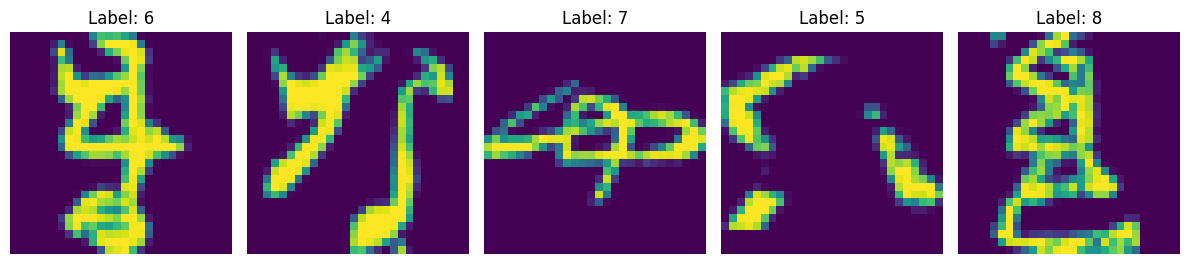


Number of Classes: 10


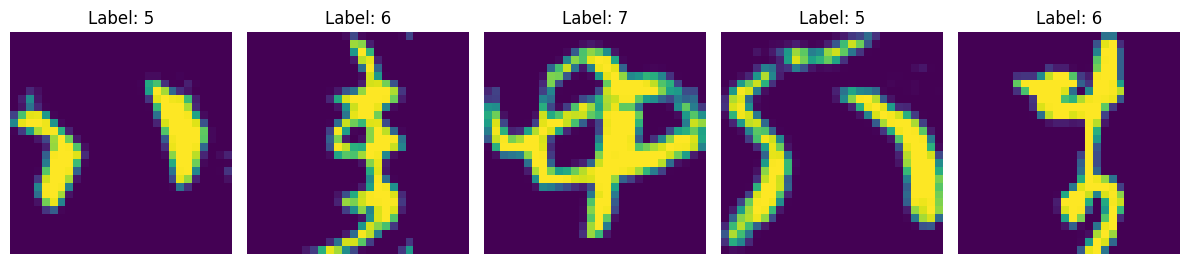


MODEL ARCHITECTURE
DeepQNN(
  (simam): SIMAM()
  (classical): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 236,258
Trainable Parameters : 236,258
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/127 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 1.3147 | Train Acc: 59.21% | Val Loss: 0.6762 | Val Acc: 87.72%


Epoch 2/25 [Train]:   0%|          | 0/591 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/127 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 0.0203 | Train Acc: 99.50% | Val Loss: 0.3225 | Val Acc: 95.53%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 89.07%

Sample Prediction
-----------------
True Label     : 2
Predicted Label: 5


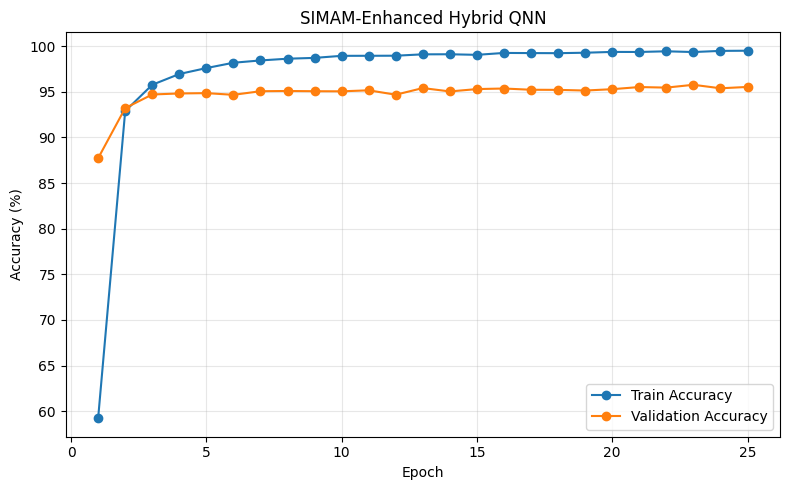

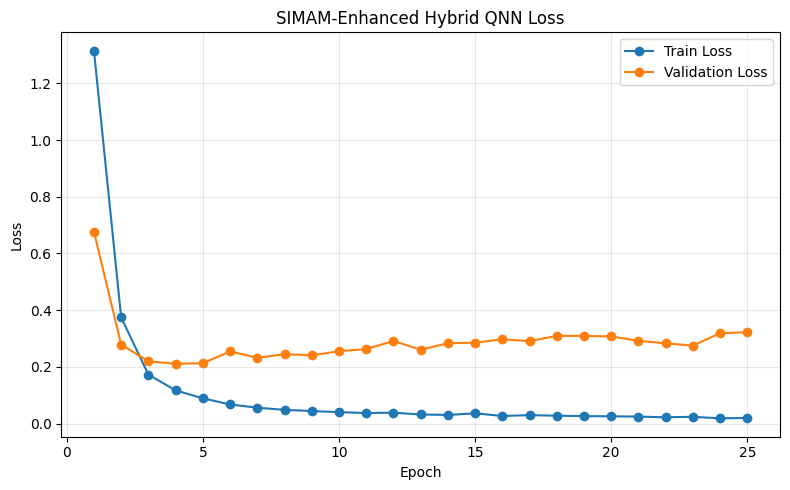

In [11]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

# ============================================================
# Dataset & Data Processing
# ============================================================

# ------------------------------------------------------------
# Dataset Fractions
# ------------------------------------------------------------

DATASET_FRACTION = 0.90

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
INTERNAL_TEST_FRACTION = 0.15


# ============================================================
# Transform
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    ),
])


# ============================================================
# Load Full FashionMNIST Training Dataset
# ============================================================

full_train_dataset = datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# ============================================================
# Load Official FashionMNIST Test Dataset
#
# IMPORTANT:
# This dataset is completely untouched.
# It is used ONLY for final evaluation.
# ============================================================

official_test_dataset = datasets.KMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Select 10% of Original Training Dataset
# ============================================================

total_train_samples = len(full_train_dataset)

selected_size = int(
    total_train_samples * DATASET_FRACTION
)


selected_dataset, _ = random_split(
    full_train_dataset,
    [
        selected_size,
        total_train_samples - selected_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Split Selected 10%
#
# 70% → Train
# 15% → Validation
# 15% → Internal Test
#
# Overall:
#
# 10% × 70% = 7%
# 10% × 15% = 1.5%
# 10% × 15% = 1.5%
# ============================================================

train_size = int(
    selected_size * TRAIN_FRACTION
)

val_size = int(
    selected_size * VAL_FRACTION
)

internal_test_size = (
    selected_size
    - train_size
    - val_size
)


train_dataset, val_dataset, internal_test_dataset = random_split(
    selected_dataset,
    [
        train_size,
        val_size,
        internal_test_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Dataset Information
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(
    f"Original FashionMNIST training dataset : "
    f"{total_train_samples:,}"
)

print(
    f"Selected dataset fraction               : "
    f"{DATASET_FRACTION * 100:.1f}%"
)

print(
    f"Selected samples                        : "
    f"{selected_size:,}"
)

print(
    f"Training samples                        : "
    f"{len(train_dataset):,} "
    f"({len(train_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Validation samples                      : "
    f"{len(val_dataset):,} "
    f"({len(val_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Internal test samples                   : "
    f"{len(internal_test_dataset):,} "
    f"({len(internal_test_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Official test samples                   : "
    f"{len(official_test_dataset):,}"
)

print("=" * 60)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Official FashionMNIST test set
test_loader = DataLoader(
    official_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Recover Original Indices
# ============================================================

selected_indices = selected_dataset.indices

train_indices = train_dataset.indices
val_indices = val_dataset.indices
internal_test_indices = internal_test_dataset.indices


train_original_indices = [
    selected_indices[i]
    for i in train_indices
]

val_original_indices = [
    selected_indices[i]
    for i in val_indices
]

internal_test_original_indices = [
    selected_indices[i]
    for i in internal_test_indices
]


# ============================================================
# Extract Labels
# ============================================================

train_labels = (
    full_train_dataset
    .targets[train_original_indices]
    .numpy()
)

val_labels = (
    full_train_dataset
    .targets[val_original_indices]
    .numpy()
)

internal_test_labels = (
    full_train_dataset
    .targets[internal_test_original_indices]
    .numpy()
)

official_test_labels = (
    official_test_dataset
    .targets
    .numpy()
)


# ============================================================
# Class Distribution
# ============================================================

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nValidation class distribution:")
print(Counter(val_labels))

print("\nInternal test class distribution:")
print(Counter(internal_test_labels))

print("\nOfficial test class distribution:")
print(Counter(official_test_labels))


# ============================================================
# Class Weights
# ============================================================
#
# IMPORTANT:
# Calculate class weights ONLY from training data.
# Do NOT use validation or test labels.
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)


print("\nClass Weights:")
print("-" * 30)

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# Number of Classes
# ============================================================

NUM_CLASSES = len(
    torch.unique(
        full_train_dataset.targets
    )
)

print(
    f"\nNumber of Classes: {NUM_CLASSES}"
)

# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(
        img,
        # cmap="gray"
    )

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

class DeepQNN(nn.Module):

    def __init__(self):

        super().__init__()


        # ====================================================
        # 1. SIMAM Attention
        # ====================================================

        self.simam = SIMAM(
            e_lambda=SIMAM_E_LAMBDA
        )


        # ====================================================
        # 2. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 784 → 256
            nn.Linear(
                784,
                256
            ),

            nn.ReLU(),


            # 256 → 128
            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            # 128 → NUM_QUBITS
            nn.Linear(
                128,
                NUM_QUBITS
            )

        )


        # ====================================================
        # 3. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer


        # ====================================================
        # 4. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # NUM_QUBITS → 64
            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.ReLU(),


            # 64 → 10
            nn.Linear(
                64,
                10
            )

        )


    # ========================================================
    # Forward Pass
    # ========================================================

    def forward(self, x):


        # ====================================================
        # STEP 1 — Input
        # ====================================================
        #
        # x:
        #
        # [B, 1, 28, 28]
        #
        # ====================================================


        # ====================================================
        # STEP 2 — SIMAM
        # ====================================================

        x = self.simam(x)


        # ====================================================
        # STEP 3 — Flatten
        # ====================================================
        #
        # [B, 1, 28, 28]
        #
        #        ↓
        #
        # [B, 784]
        #
        # ====================================================

        x = x.flatten(
            start_dim=1
        )


        # ====================================================
        # STEP 4 — Classical Feature Extraction
        # ====================================================
        #
        # 784 → 256 → 128 → NUM_QUBITS
        #
        # ====================================================

        x = self.classical(x)


        # ====================================================
        # STEP 5 — Bound Quantum Angles
        # ====================================================
        #
        # tanh:
        #
        # [-∞, +∞] → [-1, +1]
        #
        # × π:
        #
        # [-1, +1] → [-π, +π]
        #
        # ====================================================

        x = torch.tanh(x) * np.pi


        # ====================================================
        # STEP 6 — Quantum Circuit
        # ====================================================

        quantum_device = x.device


        # default.qubit runs on CPU
        x = self.quantum(
            x.cpu()
        )


        # Move quantum output back
        # to original device

        x = x.to(
            quantum_device
        )


        # ====================================================
        # STEP 7 — Classical Classifier
        # ====================================================
        #
        # NUM_QUBITS → 64 → 10
        #
        # ====================================================

        x = self.classifier(x)


        return x


# ============================================================
# Create Model
# ============================================================

model = DeepQNN().to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)

# ============================================================
# Predict One Official Test Sample
# ============================================================

image, label = official_test_dataset[0]

model.eval()

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(DEVICE)
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)

# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()